In [1]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from scipy import ndimage

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
train_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/images'
train_mask_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/masks'
val_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/images'
val_mask_dir =  '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/masks'
sam_checkpoint = "/home/iiitdmk-param/Desktop/Research/3/Data/sam_vit_b.pth"
model_type = "vit_b"

# Training parameters
BATCH_SIZE = 4
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_CLASSES = 18

# Topological loss parameters
TOPO_LOSS_WEIGHT = 0.3  # Weight for topological loss

# ==================== CLASS INFORMATION ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# ==================== TOPOLOGICAL LOSS ====================
class TopologicalLoss(nn.Module):
    def __init__(self, class_weights=None, eps=1e-8):
        """
        Topological loss for semantic segmentation
        Focuses on preserving connectivity and shape structure
        """
        super().__init__()
        self.eps = eps
        
        # Class-specific topological importance weights
        if class_weights is None:
            self.class_weights = {
                3: 1.0,   # buildings - high (solid, connected shapes)
                11: 1.2,  # pavement - very high (connectivity critical)
                13: 0.8,  # sea - medium (boundary smoothness)
                17: 0.8,  # water - medium (boundary smoothness)
                8: 0.5,   # field - low (some shape consistency)
                5: 0.4,   # chaparral - low
                9: 0.4,   # grass - low
                16: 0.4,  # trees - low
                # Other classes get default weight
            }
        else:
            self.class_weights = class_weights
            
        self.default_weight = 0.1

    def compute_component_loss(self, pred_binary, target_binary):
        """Compute loss for connected components (0D topology)"""
        if pred_binary.sum() == 0 and target_binary.sum() == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        # Convert to numpy for connected component analysis
        pred_np = pred_binary.cpu().numpy().astype(np.uint8)
        target_np = target_binary.cpu().numpy().astype(np.uint8)
        
        # Count connected components
        pred_components, _ = ndimage.label(pred_np)
        target_components, _ = ndimage.label(target_np)
        
        pred_count = np.max(pred_components) if np.max(pred_components) > 0 else 0
        target_count = np.max(target_components) if np.max(target_components) > 0 else 0
        
        # Component count difference
        comp_diff = torch.abs(torch.tensor(pred_count - target_count, dtype=torch.float32, device=pred_binary.device))
        
        return comp_diff

    def compute_boundary_loss(self, pred_binary, target_binary):
        """Compute boundary consistency loss"""
        if pred_binary.sum() == 0 and target_binary.sum() == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        # Convert to numpy for morphological operations
        pred_np = pred_binary.cpu().numpy().astype(np.uint8)
        target_np = target_binary.cpu().numpy().astype(np.uint8)
        
        # Compute boundaries using erosion
        kernel = np.ones((3, 3), np.uint8)
        pred_boundary = cv2.morphologyEx(pred_np, cv2.MORPH_GRADIENT, kernel)
        target_boundary = cv2.morphologyEx(target_np, cv2.MORPH_GRADIENT, kernel)
        
        # Boundary consistency
        boundary_intersection = np.logical_and(pred_boundary, target_boundary).sum()
        boundary_union = np.logical_or(pred_boundary, target_boundary).sum()
        
        if boundary_union == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        boundary_iou = boundary_intersection / boundary_union
        boundary_loss = 1.0 - boundary_iou
        
        return torch.tensor(boundary_loss, dtype=torch.float32, device=pred_binary.device)

    def forward(self, pred_masks, target_masks):
        """
        Compute topological loss between predictions and targets
        
        Args:
            pred_masks: Tensor of shape [B, H, W] with class indices
            target_masks: Tensor of shape [B, H, W] with class indices
        """
        batch_size = pred_masks.shape[0]
        total_loss = 0.0
        valid_classes_count = 0
        
        for batch_idx in range(batch_size):
            pred_mask = pred_masks[batch_idx]
            target_mask = target_masks[batch_idx]
            
            # Get unique classes in this batch item
            unique_classes = torch.unique(torch.cat([pred_mask, target_mask]))
            
            for class_id in unique_classes:
                class_id = class_id.item()
                if class_id == 0:  # Skip background
                    continue
                    
                class_weight = self.class_weights.get(class_id, self.default_weight)
                if class_weight == 0:
                    continue
                
                # Extract binary masks for this class
                pred_binary = (pred_mask == class_id).float()
                target_binary = (target_mask == class_id).float()
                
                # Skip if both are empty
                if pred_binary.sum() == 0 and target_binary.sum() == 0:
                    continue
                
                class_loss = 0.0
                
                # 1. Component count loss
                comp_loss = self.compute_component_loss(pred_binary, target_binary)
                class_loss += comp_loss
                
                # 2. Boundary consistency loss
                boundary_loss = self.compute_boundary_loss(pred_binary, target_binary)
                class_loss += boundary_loss
                
                total_loss += class_weight * class_loss
                valid_classes_count += 1
        
        # Normalize by number of valid class comparisons
        if valid_classes_count > 0:
            total_loss = total_loss / valid_classes_count
        
        return total_loss

# ==================== COMBINED LOSS ====================
class CombinedLoss(nn.Module):
    def __init__(self, topo_weight=TOPO_LOSS_WEIGHT):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss()
        self.topo_loss = TopologicalLoss()
        self.topo_weight = topo_weight
    
    def forward(self, logits, targets, pred_masks=None):
        # Standard cross entropy loss
        ce_loss = self.ce_loss(logits, targets)
        
        # Topological loss (if pred_masks are provided)
        if pred_masks is not None:
            topo_loss = self.topo_loss(pred_masks, targets)
            total_loss = ce_loss + self.topo_weight * topo_loss
            return total_loss, ce_loss, topo_loss
        else:
            return ce_loss, ce_loss, torch.tensor(0.0)

# ==================== SIMPLE DATA TRANSFORM ====================
class SimpleTransform:
    def __call__(self, image, mask):
        # Resize to 256x256 and normalize
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        # Normalize image
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()
        
        return image, mask

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        # Simple segmentation head
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        # Freeze SAM encoder
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False
    
    def unfreeze_encoder(self, percentage=0.5):
        total_layers = len(list(self.sam.image_encoder.parameters()))
        layers_to_unfreeze = int(total_layers * percentage)
        
        for i, param in enumerate(self.sam.image_encoder.parameters()):
            if i >= (total_layers - layers_to_unfreeze):
                param.requires_grad = True
    
    def forward(self, x):
        # Input should be 1024x1024 for SAM
        image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== DATASET ====================
class HighIoUDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        self.image_files = sorted([f for f in os.listdir(image_dir) 
                                 if f.endswith(('.png', '.jpg', '.jpeg', '.tif'))])
        
        print(f"Found {len(self.image_files)} images in {image_dir}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        base_name = os.path.splitext(self.image_files[idx])[0]
        mask_path = os.path.join(self.mask_dir, base_name + '.png')
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not load mask: {mask_path}")
        
        # Apply transformations
        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            # Default processing
            image = cv2.resize(image, (256, 256))
            mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        
        return {'image': image, 'mask': mask}

# ==================== FIXED METRICS ====================
def calculate_iou(pred_mask, true_mask, num_classes):
    ious = []
    
    for class_id in range(num_classes):
        pred_inds = (pred_mask == class_id)
        target_inds = (true_mask == class_id)
        
        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(float(intersection / union))
    
    return np.nanmean(ious)

# ==================== MODIFIED TRAINING FUNCTION ====================
def train_high_iou_sam():
    print("=== PHASE 1: HIGH IoU SAM TRAINING WITH TOPOLOGICAL LOSS ===")
    print(f"Using batch size: {BATCH_SIZE}")
    print(f"Topological loss weight: {TOPO_LOSS_WEIGHT}")
    
    # Load SAM model
    print("Loading SAM model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    model = HighIoUSAMWrapper(sam, NUM_CLASSES).to(device)
    
    # Create datasets
    transform = SimpleTransform()
    train_dataset = HighIoUDataset(train_image_dir, train_mask_dir, transform)
    val_dataset = HighIoUDataset(val_image_dir, val_mask_dir, transform)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Use combined loss with topological component
    criterion = CombinedLoss(topo_weight=TOPO_LOSS_WEIGHT)
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)
    
    best_iou = 0.0
    
    print("Starting training with topological loss...")
    for epoch in range(NUM_EPOCHS):
        # Training phase
        model.train()
        epoch_total_loss = 0
        epoch_ce_loss = 0
        epoch_topo_loss = 0
        num_batches = 0
        
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            # Ensure masks are long type
            if masks.dtype != torch.long:
                masks = masks.long()
            
            optimizer.zero_grad()
            
            # Resize images to 1024x1024 for SAM
            images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
            
            # Forward pass
            logits = model(images_resized)
            
            # Resize logits back to 256x256
            logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
            
            # Get predicted masks for topological loss
            pred_masks = torch.argmax(logits, dim=1)
            
            # Compute combined loss
            total_loss, ce_loss, topo_loss = criterion(logits, masks, pred_masks)
            
            total_loss.backward()
            optimizer.step()
            
            epoch_total_loss += total_loss.item()
            epoch_ce_loss += ce_loss.item()
            epoch_topo_loss += topo_loss.item()
            num_batches += 1
            
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}: '
                      f'Total Loss: {total_loss.item():.4f}, '
                      f'CE: {ce_loss.item():.4f}, '
                      f'Topo: {topo_loss.item():.4f}')
        
        avg_total_loss = epoch_total_loss / num_batches
        avg_ce_loss = epoch_ce_loss / num_batches
        avg_topo_loss = epoch_topo_loss / num_batches
        
        # Validation phase
        model.eval()
        val_iou = 0
        num_val_samples = 0
        
        with torch.no_grad():
            for val_batch in val_loader:
                images = val_batch['image'].to(device)
                masks = val_batch['mask'].to(device)
                
                if masks.dtype != torch.long:
                    masks = masks.long()
                
                images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
                logits = model(images_resized)
                logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
                pred_masks = torch.argmax(logits, dim=1)
                
                for i in range(pred_masks.shape[0]):
                    iou = calculate_iou(pred_masks[i].cpu().numpy(), masks[i].cpu().numpy(), NUM_CLASSES)
                    val_iou += iou
                    num_val_samples += 1
        
        avg_val_iou = val_iou / num_val_samples if num_val_samples > 0 else 0
        scheduler.step(avg_val_iou)
        
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}:')
        print(f'  Train - Total: {avg_total_loss:.4f}, CE: {avg_ce_loss:.4f}, Topo: {avg_topo_loss:.4f}')
        print(f'  Val IoU: {avg_val_iou:.4f}')
        
        if avg_val_iou > best_iou:
            best_iou = avg_val_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_total_loss,
                'iou': best_iou,
                'ce_loss': avg_ce_loss,
                'topo_loss': avg_topo_loss,
            }, 'topo_retrain_best_high_iou_sam.pth')
            print(f'✅ Saved new best model with IoU: {best_iou:.4f}')
        
        # Gradually unfreeze encoder
        if epoch == 20:
            model.unfreeze_encoder(0.3)
            print("🔄 Unfrozen 30% of encoder layers")
        elif epoch == 40:
            model.unfreeze_encoder(0.6)
            print("🔄 Unfrozen 60% of encoder layers")
        elif epoch == 60:
            model.unfreeze_encoder(1.0)
            print("🔄 Unfrozen all encoder layers")
        
        if best_iou > 0.85 and epoch > 50:
            print(f"🎯 Good IoU achieved! Stopping early at epoch {epoch+1}")
            break
    
    print(f"=== TRAINING COMPLETED ===")
    print(f"Best validation IoU: {best_iou:.4f}")
    
    return model, best_iou

# ==================== MAIN EXECUTION ====================
if __name__ == "__main__":
    trained_model, final_iou = train_high_iou_sam()
    
    print(f"\n🎯 PHASE 1 COMPLETED with IoU: {final_iou:.4f}")
    
    if final_iou >= 0.85:
        print("✅ Ready for Phase 2: Weak data processing")
    else:
        print("❌ Need to improve Phase 1")

Using device: cuda
=== PHASE 1: HIGH IoU SAM TRAINING WITH TOPOLOGICAL LOSS ===
Using batch size: 4
Topological loss weight: 0.3
Loading SAM model...


/home/iiitdmk-param/AMB/Proposed_3/SAM/segment-anything-main/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Found 1157 images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/images
Found 1157 images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/images
Training samples: 1157
Validation samples: 1157
Starting training with topological loss...


/home/iiitdmk-param/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0: Total Loss: 10.0323, CE: 3.0502, Topo: 23.2736
Epoch 1, Batch 10: Total Loss: 8.1854, CE: 2.8620, Topo: 17.7445
Epoch 1, Batch 20: Total Loss: 10.5190, CE: 2.9081, Topo: 25.3697
Epoch 1, Batch 30: Total Loss: 7.3975, CE: 2.4809, Topo: 16.3889
Epoch 1, Batch 40: Total Loss: 5.8261, CE: 2.4761, Topo: 11.1667
Epoch 1, Batch 50: Total Loss: 21.7691, CE: 2.4894, Topo: 64.2657
Epoch 1, Batch 60: Total Loss: 5.2079, CE: 2.3803, Topo: 9.4253
Epoch 1, Batch 70: Total Loss: 21.4428, CE: 2.1749, Topo: 64.2262
Epoch 1, Batch 80: Total Loss: 8.3091, CE: 2.2574, Topo: 20.1722
Epoch 1, Batch 90: Total Loss: 4.3874, CE: 2.1799, Topo: 7.3583
Epoch 1, Batch 100: Total Loss: 5.2301, CE: 2.5461, Topo: 8.9465
Epoch 1, Batch 110: Total Loss: 6.3226, CE: 2.0068, Topo: 14.3859
Epoch 1, Batch 120: Total Loss: 5.5409, CE: 2.6436, Topo: 9.6576
Epoch 1, Batch 130: Total Loss: 5.4600, CE: 2.1641, Topo: 10.9865
Epoch 1, Batch 140: Total Loss: 6.4219, CE: 2.1473, Topo: 14.2489
Epoch 1, Batch 150: T

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.00 GiB. GPU 0 has a total capacity of 23.67 GiB of which 469.69 MiB is free. Process 20659 has 978.00 MiB memory in use. Process 717764 has 7.67 GiB memory in use. Including non-PyTorch memory, this process has 14.19 GiB memory in use. Of the allocated memory 12.52 GiB is allocated by PyTorch, and 1.41 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [2]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from scipy import ndimage

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
train_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/images'
train_mask_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/masks'
val_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/images'
val_mask_dir =  '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/masks'
sam_checkpoint = "/home/iiitdmk-param/Desktop/Research/3/Data/sam_vit_b.pth"
model_type = "vit_b"

# Training parameters - REDUCED BATCH SIZE
BATCH_SIZE = 2  # Reduced from 4 to 2 to fix OOM
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_CLASSES = 18

# Topological loss parameters
TOPO_LOSS_WEIGHT = 0.3  # Weight for topological loss

# ==================== CLASS INFORMATION ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# ==================== TOPOLOGICAL LOSS ====================
class TopologicalLoss(nn.Module):
    def __init__(self, class_weights=None, eps=1e-8):
        """
        Topological loss for semantic segmentation
        Focuses on preserving connectivity and shape structure
        """
        super().__init__()
        self.eps = eps
        
        # Class-specific topological importance weights
        if class_weights is None:
            self.class_weights = {
                3: 1.0,   # buildings - high (solid, connected shapes)
                11: 1.2,  # pavement - very high (connectivity critical)
                13: 0.8,  # sea - medium (boundary smoothness)
                17: 0.8,  # water - medium (boundary smoothness)
                8: 0.5,   # field - low (some shape consistency)
                5: 0.4,   # chaparral - low
                9: 0.4,   # grass - low
                16: 0.4,  # trees - low
                # Other classes get default weight
            }
        else:
            self.class_weights = class_weights
            
        self.default_weight = 0.1

    def compute_component_loss(self, pred_binary, target_binary):
        """Compute loss for connected components (0D topology)"""
        if pred_binary.sum() == 0 and target_binary.sum() == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        # Convert to numpy for connected component analysis
        pred_np = pred_binary.cpu().numpy().astype(np.uint8)
        target_np = target_binary.cpu().numpy().astype(np.uint8)
        
        # Count connected components
        pred_components, _ = ndimage.label(pred_np)
        target_components, _ = ndimage.label(target_np)
        
        pred_count = np.max(pred_components) if np.max(pred_components) > 0 else 0
        target_count = np.max(target_components) if np.max(target_components) > 0 else 0
        
        # Component count difference
        comp_diff = torch.abs(torch.tensor(pred_count - target_count, dtype=torch.float32, device=pred_binary.device))
        
        return comp_diff

    def compute_boundary_loss(self, pred_binary, target_binary):
        """Compute boundary consistency loss"""
        if pred_binary.sum() == 0 and target_binary.sum() == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        # Convert to numpy for morphological operations
        pred_np = pred_binary.cpu().numpy().astype(np.uint8)
        target_np = target_binary.cpu().numpy().astype(np.uint8)
        
        # Compute boundaries using erosion
        kernel = np.ones((3, 3), np.uint8)
        pred_boundary = cv2.morphologyEx(pred_np, cv2.MORPH_GRADIENT, kernel)
        target_boundary = cv2.morphologyEx(target_np, cv2.MORPH_GRADIENT, kernel)
        
        # Boundary consistency
        boundary_intersection = np.logical_and(pred_boundary, target_boundary).sum()
        boundary_union = np.logical_or(pred_boundary, target_boundary).sum()
        
        if boundary_union == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        boundary_iou = boundary_intersection / boundary_union
        boundary_loss = 1.0 - boundary_iou
        
        return torch.tensor(boundary_loss, dtype=torch.float32, device=pred_binary.device)

    def forward(self, pred_masks, target_masks):
        """
        Compute topological loss between predictions and targets
        
        Args:
            pred_masks: Tensor of shape [B, H, W] with class indices
            target_masks: Tensor of shape [B, H, W] with class indices
        """
        batch_size = pred_masks.shape[0]
        total_loss = 0.0
        valid_classes_count = 0
        
        for batch_idx in range(batch_size):
            pred_mask = pred_masks[batch_idx]
            target_mask = target_masks[batch_idx]
            
            # Get unique classes in this batch item
            unique_classes = torch.unique(torch.cat([pred_mask, target_mask]))
            
            for class_id in unique_classes:
                class_id = class_id.item()
                if class_id == 0:  # Skip background
                    continue
                    
                class_weight = self.class_weights.get(class_id, self.default_weight)
                if class_weight == 0:
                    continue
                
                # Extract binary masks for this class
                pred_binary = (pred_mask == class_id).float()
                target_binary = (target_mask == class_id).float()
                
                # Skip if both are empty
                if pred_binary.sum() == 0 and target_binary.sum() == 0:
                    continue
                
                class_loss = 0.0
                
                # 1. Component count loss
                comp_loss = self.compute_component_loss(pred_binary, target_binary)
                class_loss += comp_loss
                
                # 2. Boundary consistency loss
                boundary_loss = self.compute_boundary_loss(pred_binary, target_binary)
                class_loss += boundary_loss
                
                total_loss += class_weight * class_loss
                valid_classes_count += 1
        
        # Normalize by number of valid class comparisons
        if valid_classes_count > 0:
            total_loss = total_loss / valid_classes_count
        
        return total_loss

# ==================== COMBINED LOSS ====================
class CombinedLoss(nn.Module):
    def __init__(self, topo_weight=TOPO_LOSS_WEIGHT):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss()
        self.topo_loss = TopologicalLoss()
        self.topo_weight = topo_weight
    
    def forward(self, logits, targets, pred_masks=None):
        # Standard cross entropy loss
        ce_loss = self.ce_loss(logits, targets)
        
        # Topological loss (if pred_masks are provided)
        if pred_masks is not None:
            topo_loss = self.topo_loss(pred_masks, targets)
            total_loss = ce_loss + self.topo_weight * topo_loss
            return total_loss, ce_loss, topo_loss
        else:
            return ce_loss, ce_loss, torch.tensor(0.0)

# ==================== SIMPLE DATA TRANSFORM ====================
class SimpleTransform:
    def __call__(self, image, mask):
        # Resize to 256x256 and normalize
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        # Normalize image
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()
        
        return image, mask

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        # Simple segmentation head
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        # Freeze SAM encoder
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False
    
    def unfreeze_encoder(self, percentage=0.5):
        total_layers = len(list(self.sam.image_encoder.parameters()))
        layers_to_unfreeze = int(total_layers * percentage)
        
        for i, param in enumerate(self.sam.image_encoder.parameters()):
            if i >= (total_layers - layers_to_unfreeze):
                param.requires_grad = True
    
    def forward(self, x):
        # Input should be 1024x1024 for SAM
        image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== DATASET ====================
class HighIoUDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        
        self.image_files = sorted([f for f in os.listdir(image_dir) 
                                 if f.endswith(('.png', '.jpg', '.jpeg', '.tif'))])
        
        print(f"Found {len(self.image_files)} images in {image_dir}")
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        base_name = os.path.splitext(self.image_files[idx])[0]
        mask_path = os.path.join(self.mask_dir, base_name + '.png')
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not load mask: {mask_path}")
        
        # Apply transformations
        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            # Default processing
            image = cv2.resize(image, (256, 256))
            mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()
        
        return {'image': image, 'mask': mask}

# ==================== FIXED METRICS ====================
def calculate_iou(pred_mask, true_mask, num_classes):
    ious = []
    
    for class_id in range(num_classes):
        pred_inds = (pred_mask == class_id)
        target_inds = (true_mask == class_id)
        
        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(float(intersection / union))
    
    return np.nanmean(ious)

# ==================== MODIFIED TRAINING FUNCTION ====================
def train_high_iou_sam():
    print("=== PHASE 1: HIGH IoU SAM TRAINING WITH TOPOLOGICAL LOSS ===")
    print(f"Using batch size: {BATCH_SIZE} (reduced for memory)")
    print(f"Topological loss weight: {TOPO_LOSS_WEIGHT}")
    
    # Load SAM model
    print("Loading SAM model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    model = HighIoUSAMWrapper(sam, NUM_CLASSES).to(device)
    
    # Check if we have a saved model to continue from
    start_epoch = 0
    if os.path.exists('topo_retrain_best_high_iou_sam.pth'):
        print("🔄 Found saved model! Continuing from checkpoint...")
        checkpoint = torch.load('topo_retrain_best_high_iou_sam.pth', map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Continuing from epoch {start_epoch} with IoU: {checkpoint['iou']:.4f}")
    
    # Create datasets
    transform = SimpleTransform()
    train_dataset = HighIoUDataset(train_image_dir, train_mask_dir, transform)
    val_dataset = HighIoUDataset(val_image_dir, val_mask_dir, transform)
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Use combined loss with topological component
    criterion = CombinedLoss(topo_weight=TOPO_LOSS_WEIGHT)
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)
    
    # Load optimizer state if continuing
    if os.path.exists('topo_retrain_best_high_iou_sam.pth'):
        checkpoint = torch.load('topo_retrain_best_high_iou_sam.pth', map_location=device)
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        best_iou = checkpoint['iou']
    else:
        best_iou = 0.0
    
    print("Starting training with topological loss...")
    for epoch in range(start_epoch, NUM_EPOCHS):
        # Training phase
        model.train()
        epoch_total_loss = 0
        epoch_ce_loss = 0
        epoch_topo_loss = 0
        num_batches = 0
        
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            # Ensure masks are long type
            if masks.dtype != torch.long:
                masks = masks.long()
            
            optimizer.zero_grad()
            
            # Resize images to 1024x1024 for SAM
            images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
            
            # Forward pass
            logits = model(images_resized)
            
            # Resize logits back to 256x256
            logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
            
            # Get predicted masks for topological loss
            pred_masks = torch.argmax(logits, dim=1)
            
            # Compute combined loss
            total_loss, ce_loss, topo_loss = criterion(logits, masks, pred_masks)
            
            total_loss.backward()
            optimizer.step()
            
            epoch_total_loss += total_loss.item()
            epoch_ce_loss += ce_loss.item()
            epoch_topo_loss += topo_loss.item()
            num_batches += 1
            
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}: '
                      f'Total Loss: {total_loss.item():.4f}, '
                      f'CE: {ce_loss.item():.4f}, '
                      f'Topo: {topo_loss.item():.4f}')
        
        avg_total_loss = epoch_total_loss / num_batches
        avg_ce_loss = epoch_ce_loss / num_batches
        avg_topo_loss = epoch_topo_loss / num_batches
        
        # Validation phase
        model.eval()
        val_iou = 0
        num_val_samples = 0
        
        with torch.no_grad():
            for val_batch in val_loader:
                images = val_batch['image'].to(device)
                masks = val_batch['mask'].to(device)
                
                if masks.dtype != torch.long:
                    masks = masks.long()
                
                images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
                logits = model(images_resized)
                logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
                pred_masks = torch.argmax(logits, dim=1)
                
                for i in range(pred_masks.shape[0]):
                    iou = calculate_iou(pred_masks[i].cpu().numpy(), masks[i].cpu().numpy(), NUM_CLASSES)
                    val_iou += iou
                    num_val_samples += 1
        
        avg_val_iou = val_iou / num_val_samples if num_val_samples > 0 else 0
        scheduler.step(avg_val_iou)
        
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}:')
        print(f'  Train - Total: {avg_total_loss:.4f}, CE: {avg_ce_loss:.4f}, Topo: {avg_topo_loss:.4f}')
        print(f'  Val IoU: {avg_val_iou:.4f}')
        
        if avg_val_iou > best_iou:
            best_iou = avg_val_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_total_loss,
                'iou': best_iou,
                'ce_loss': avg_ce_loss,
                'topo_loss': avg_topo_loss,
            }, 'topo_retrain_best_high_iou_sam.pth')
            print(f'✅ Saved new best model with IoU: {best_iou:.4f}')
        
        # Gradually unfreeze encoder (adjust based on current epoch)
        if epoch == 20 and epoch >= start_epoch:
            model.unfreeze_encoder(0.3)
            print("🔄 Unfrozen 30% of encoder layers")
        elif epoch == 40 and epoch >= start_epoch:
            model.unfreeze_encoder(0.6)
            print("🔄 Unfrozen 60% of encoder layers")
        elif epoch == 60 and epoch >= start_epoch:
            model.unfreeze_encoder(1.0)
            print("🔄 Unfrozen all encoder layers")
    
    print(f"=== TRAINING COMPLETED ===")
    print(f"Best validation IoU: {best_iou:.4f}")
    
    return model, best_iou

# ==================== MAIN EXECUTION ====================
if __name__ == "__main__":
    trained_model, final_iou = train_high_iou_sam()
    
    print(f"\n🎯 PHASE 1 COMPLETED with IoU: {final_iou:.4f}")
    
    if final_iou >= 0.85:
        print("✅ Ready for Phase 2: Weak data processing")
    else:
        print("❌ Need to improve Phase 1")

Using device: cuda
=== PHASE 1: HIGH IoU SAM TRAINING WITH TOPOLOGICAL LOSS ===
Using batch size: 2 (reduced for memory)
Topological loss weight: 0.3
Loading SAM model...


/home/iiitdmk-param/AMB/Proposed_3/SAM/segment-anything-main/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


🔄 Found saved model! Continuing from checkpoint...


/tmp/ipykernel_257474/239044059.py:336: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('topo_retrain_best_high_iou_sam.pth', map_location=device)


Continuing from epoch 20 with IoU: 0.2901
Found 1157 images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/images
Found 1157 images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/merged_training_dataset/images
Training samples: 1157
Validation samples: 1157


/home/iiitdmk-param/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/tmp/ipykernel_257474/239044059.py:360: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't hav

Starting training with topological loss...
Epoch 21, Batch 0: Total Loss: 2.9215, CE: 1.0813, Topo: 6.1339
Epoch 21, Batch 10: Total Loss: 4.3854, CE: 1.1844, Topo: 10.6701
Epoch 21, Batch 20: Total Loss: 15.3172, CE: 1.2037, Topo: 47.0447
Epoch 21, Batch 30: Total Loss: 3.8000, CE: 1.6625, Topo: 7.1251
Epoch 21, Batch 40: Total Loss: 64.1338, CE: 1.2520, Topo: 209.6059
Epoch 21, Batch 50: Total Loss: 19.0124, CE: 0.7023, Topo: 61.0336
Epoch 21, Batch 60: Total Loss: 4.7665, CE: 1.2394, Topo: 11.7567
Epoch 21, Batch 70: Total Loss: 3.8503, CE: 1.1361, Topo: 9.0473
Epoch 21, Batch 80: Total Loss: 5.7556, CE: 1.3618, Topo: 14.6460
Epoch 21, Batch 90: Total Loss: 9.6973, CE: 3.4223, Topo: 20.9167
Epoch 21, Batch 100: Total Loss: 3.4833, CE: 0.9888, Topo: 8.3149
Epoch 21, Batch 110: Total Loss: 5.3820, CE: 1.6576, Topo: 12.4147
Epoch 21, Batch 120: Total Loss: 1.9897, CE: 0.6284, Topo: 4.5375
Epoch 21, Batch 130: Total Loss: 2.7407, CE: 0.5270, Topo: 7.3787
Epoch 21, Batch 140: Total Loss:

🚀 Starting initial predictions...
🔄 Loading SAM base model...
🔄 Creating wrapper model...
🔄 Loading pre-trained weights from topo_retrain_best_high_iou_sam.pth...
✅ Loaded model from epoch 99 with val loss: 10.6050, IoU: 0.8401
📸 Found 1319 test images
💾 Saving initial predictions to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions

🎉 All initial predictions saved!


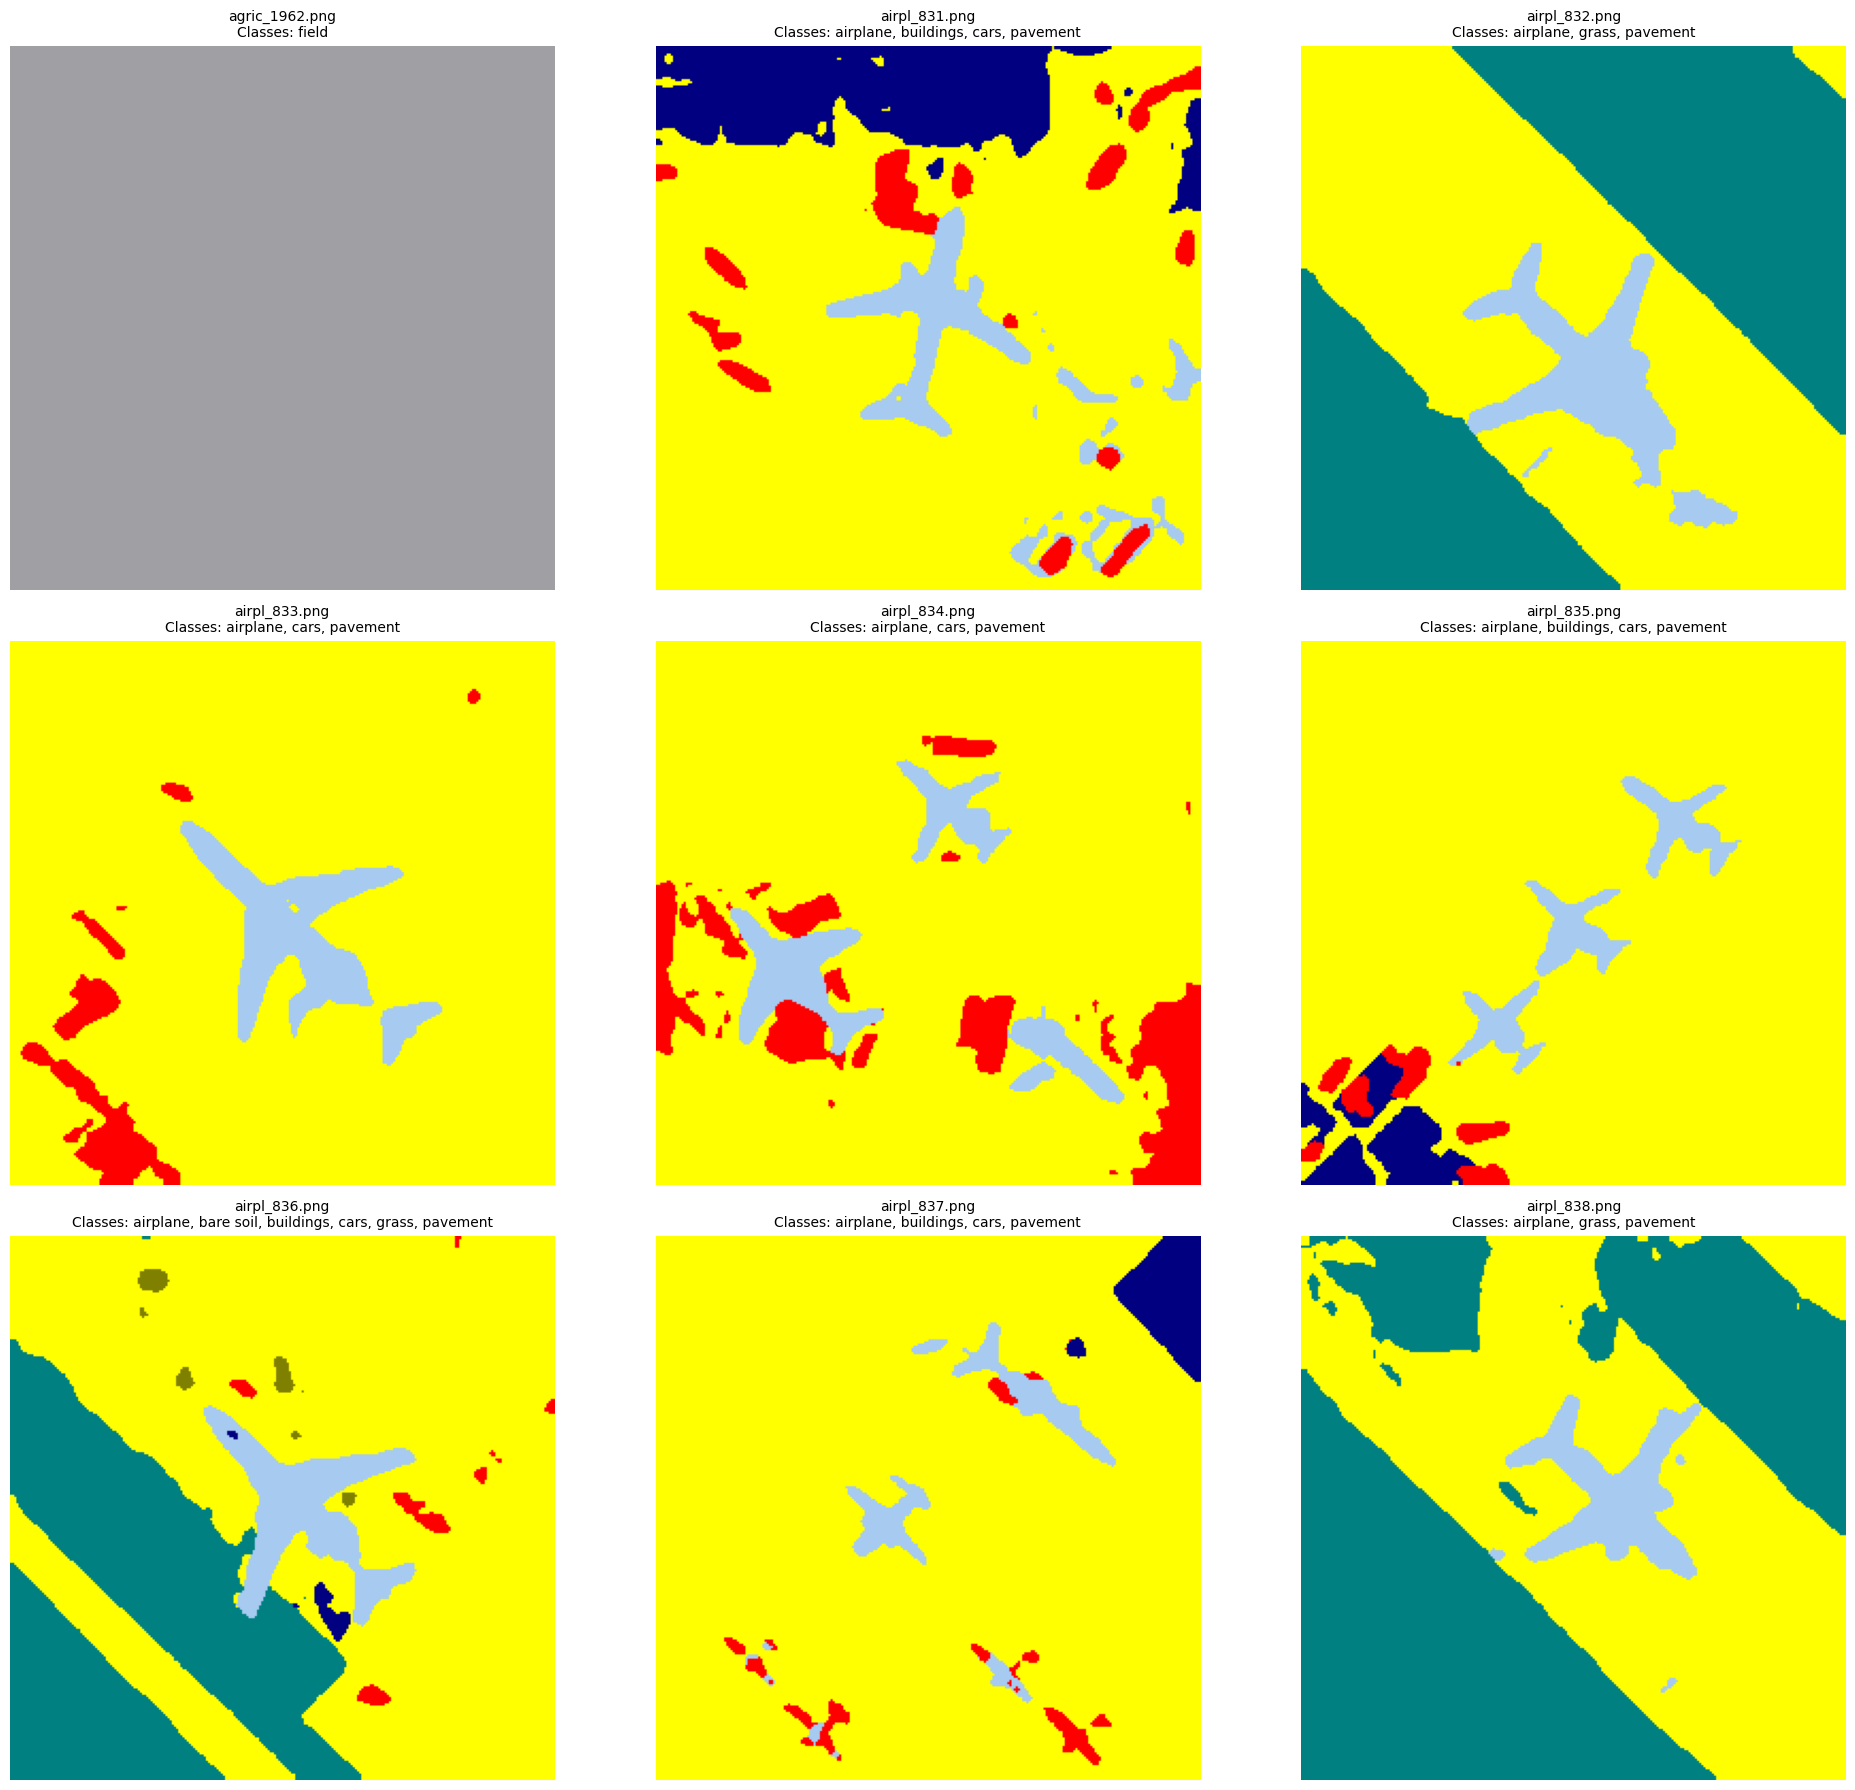


🎯 Initial predictions completed successfully!


In [3]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
initial_output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
sam_checkpoint = "/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"
pretrained_model_path = 'topo_retrain_best_high_iou_sam.pth'

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

NUM_CLASSES = len(CLASS_INFO)

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== LOAD PRE-TRAINED MODEL ====================
def load_pretrained_model(pretrained_path, sam_checkpoint, model_type, num_classes):
    print("🔄 Loading SAM base model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    print("🔄 Creating wrapper model...")
    model = HighIoUSAMWrapper(sam, num_classes)
    
    print(f"🔄 Loading pre-trained weights from {pretrained_path}...")
    
    if not os.path.exists(pretrained_path):
        raise FileNotFoundError(f"❌ Pre-trained model not found at: {pretrained_path}")
    
    checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    epoch = checkpoint.get('epoch', 'Unknown')
    loss = checkpoint.get('loss', 'Unknown')
    iou = checkpoint.get('iou', 'Unknown')
    
    try:
        loss_str = f"{float(loss):.4f}" if loss != 'Unknown' else 'Unknown'
        iou_str = f"{float(iou):.4f}" if iou != 'Unknown' else 'Unknown'
        print(f"✅ Loaded model from epoch {epoch} with val loss: {loss_str}, IoU: {iou_str}")
    except (ValueError, TypeError):
        print(f"✅ Loaded model from epoch {epoch} with val loss: {loss}, IoU: {iou}")
    
    return model

# ==================== GET INITIAL PREDICTION ====================
def get_initial_prediction(model, image_rgb, original_size, device):
    """Get initial dense 1-channel prediction using your fine-tuned model"""
    # Preprocess image
    input_image = cv2.resize(image_rgb, (1024, 1024))
    input_image = input_image.astype(np.float32) / 255.0
    input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    
    input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
    input_image_tensor = input_image_tensor.unsqueeze(0)
    
    with torch.no_grad():
        logits = model(input_image_tensor)
        logits = torch.nn.functional.interpolate(
            logits, size=original_size, mode='bilinear', align_corners=False
        )
        predictions = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    
    return predictions

# ==================== SAVE INITIAL PREDICTIONS ====================
def save_initial_predictions(model, test_image_dir, output_dir, device='cuda'):
    """Save only initial predictions without any refinement"""
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"📸 Found {len(image_files)} test images")
    print(f"💾 Saving initial predictions to: {output_dir}")
    
    for image_idx, image_file in enumerate(image_files, 1):
        image_path = os.path.join(test_image_dir, image_file)
        base_name = image_file.split('.')[0]
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"❌ Could not load image: {image_file}")
            continue
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        #print(f"[{image_idx}/{len(image_files)}] Processing {image_file}...")
        
        # Get initial 1-channel prediction
        initial_prediction = get_initial_prediction(model, image_rgb, original_size, device)
        
        # Analyze initial prediction
        initial_classes = np.unique(initial_prediction)
        initial_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in initial_classes]
        #print(f"  📊 Classes: {list(zip(initial_classes, initial_class_names))}")
        
        # Save initial prediction
        predictions_uint8 = initial_prediction.astype(np.uint8)
        output_path = os.path.join(output_dir, f'{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        #print(f"  ✅ Saved initial prediction: {output_path}")
    
    print("\n🎉 All initial predictions saved!")

# ==================== VISUALIZATION ====================
def visualize_predictions(predictions_folder, num_samples=9):
    """Visualize prediction masks with proper class colors"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    if not image_files:
        print("❌ No prediction files found for visualization")
        return
    
    num_images = min(len(image_files), num_samples)
    cols = 3
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
    if rows > 1:
        axes = axes.flatten()
    else:
        axes = [axes] if cols == 1 else axes
    
    for i, image_file in enumerate(image_files[:num_images]):
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            continue
        
        # Create colored mask using class RGB values
        colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        for class_id, info in CLASS_INFO.items():
            colored_mask[mask == class_id] = info["rgb"]
        
        axes[i].imshow(colored_mask)
        
        # Get unique classes in this mask
        unique_classes = np.unique(mask)
        class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in unique_classes]
        
        axes[i].set_title(f'{image_file}\nClasses: {", ".join(class_names)}', fontsize=10)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# ==================== MAIN EXECUTION ====================
def main():
    print("🚀 Starting initial predictions...")
    
    # Load your pre-trained fine-tuned model
    model = load_pretrained_model(pretrained_model_path, sam_checkpoint, model_type, NUM_CLASSES)
    model = model.to(device)
    model.eval()
    
    # Save only initial predictions
    save_initial_predictions(model, test_image_dir, initial_output_dir, device)
    
    # Visualize predictions
    visualize_predictions(initial_output_dir)
    
    print("\n🎯 Initial predictions completed successfully!")

if __name__ == "__main__":
    main()

In [4]:
import os
import numpy as np
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def calculate_detailed_miou(gt_folder, pred_folder, num_classes=18, ignore_index=None):
    """
    Calculate detailed mIoU with per-class results
    """
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    pred_files = sorted([f for f in os.listdir(pred_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    
    assert len(gt_files) == len(pred_files), f"Number of files don't match: GT={len(gt_files)}, Pred={len(pred_files)}"
    
    # Initialize intersection and union arrays
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)
    class_pixels = np.zeros(num_classes)  # For pixel accuracy
    
    print(f"Processing {len(gt_files)} images...")
    
    for i, (gt_file, pred_file) in enumerate(zip(gt_files, pred_files)):
        gt_path = os.path.join(gt_folder, gt_file)
        pred_path = os.path.join(pred_folder, pred_file)
        
        # Load 1-channel masks
        gt_mask = np.array(Image.open(gt_path))
        pred_mask = np.array(Image.open(pred_path))
        
        # Ensure masks have the same shape
        assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT{gt_mask.shape} vs Pred{pred_mask.shape}"
        
        # Calculate IoU for each class
        for class_id in range(num_classes):
            if ignore_index is not None and class_id == ignore_index:
                continue
                
            gt_class = (gt_mask == class_id)
            pred_class = (pred_mask == class_id)
            
            intersection = np.logical_and(gt_class, pred_class).sum()
            union = np.logical_or(gt_class, pred_class).sum()
            
            total_intersection[class_id] += intersection
            total_union[class_id] += union
            class_pixels[class_id] += gt_class.sum()
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(gt_files)} images")
    
    # Calculate IoU for each class
    iou_per_class = np.zeros(num_classes)
    for class_id in range(num_classes):
        if total_union[class_id] > 0:
            iou_per_class[class_id] = total_intersection[class_id] / total_union[class_id]
        else:
            iou_per_class[class_id] = np.nan
    
    # Calculate mIoU (mean over classes, ignoring NaN)
    valid_classes = ~np.isnan(iou_per_class)
    miou = np.mean(iou_per_class[valid_classes])
    
    # Calculate pixel accuracy
    pixel_accuracy = total_intersection.sum() / class_pixels.sum() if class_pixels.sum() > 0 else 0
    
    return miou, iou_per_class, pixel_accuracy

# Usage with detailed results
gt_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_1cmasks'
pred_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
num_classes = 18

miou, iou_per_class, pixel_acc = calculate_detailed_miou(gt_folder, pred_folder, num_classes)

print("\n" + "="*50)
print("SEMANTIC SEGMENTATION RESULTS")
print("="*50)
print(f"mIoU: {miou:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")
print("\nPer-class IoU:")
for class_id in range(num_classes):
    class_name = CLASS_INFO[class_id]["name"]
    iou = iou_per_class[class_id]
    if not np.isnan(iou):
        print(f"  {class_name:15}: {iou:.4f}")
    else:
        print(f"  {class_name:15}: No pixels")

Processing 1319 images...
Processed 100/1319 images
Processed 200/1319 images
Processed 300/1319 images
Processed 400/1319 images
Processed 500/1319 images
Processed 600/1319 images
Processed 700/1319 images
Processed 800/1319 images
Processed 900/1319 images
Processed 1000/1319 images
Processed 1100/1319 images
Processed 1200/1319 images
Processed 1300/1319 images

SEMANTIC SEGMENTATION RESULTS
mIoU: 0.6030
Pixel Accuracy: 0.7706

Per-class IoU:
  background     : No pixels
  airplane       : 0.6753
  bare soil      : 0.3823
  buildings      : 0.6490
  cars           : 0.7177
  chaparral      : 0.4494
  court          : 0.8398
  dock           : 0.4923
  field          : 0.1121
  grass          : 0.6453
  mobile home    : 0.5220
  pavement       : 0.7503
  sand           : 0.4861
  sea            : 0.8685
  ship           : 0.5474
  tanks          : 0.7498
  trees          : 0.5712
  water          : 0.7918


In [2]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Directories
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
output_rgb_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions_rgb'

# Create output directory if it doesn't exist
os.makedirs(output_rgb_dir, exist_ok=True)

# Create color mapping array
# Create a 256x3 array (for all possible 8-bit values)
color_map = np.zeros((256, 3), dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    if class_id < 256:  # Ensure we don't exceed array bounds
        color_map[class_id] = info['rgb']

# Function to convert single-channel prediction to RGB
def convert_to_rgb(prediction_path, output_path):
    # Load the single-channel image
    pred = np.array(Image.open(prediction_path))
    
    # Convert to RGB using the color map
    rgb_image = color_map[pred]
    
    # Save the RGB image
    Image.fromarray(rgb_image).save(output_path)

# Process all images in the directory
prediction_files = [f for f in os.listdir(initial_predictions_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(prediction_files)} prediction files")
print(f"Converting to RGB...")

# Process each file with progress bar
for filename in tqdm(prediction_files):
    input_path = os.path.join(initial_predictions_dir, filename)
    output_path = os.path.join(output_rgb_dir, filename)
    
    # Preserve the same file extension
    convert_to_rgb(input_path, output_path)

print(f"RGB images saved to: {output_rgb_dir}")

# Optional: Create a visualization of the color legend
def create_legend():
    legend_height = 25  # Height per class
    legend_width = 200
    legend_img = np.zeros((len(CLASS_INFO) * legend_height, legend_width, 3), dtype=np.uint8)
    
    for i, (class_id, info) in enumerate(CLASS_INFO.items()):
        # Color bar
        legend_img[i*legend_height:(i+1)*legend_height, :50] = info['rgb']
        
        # Text area
        legend_img[i*legend_height:(i+1)*legend_height, 50:] = [255, 255, 255]
    
    # Convert to PIL image to add text
    legend_pil = Image.fromarray(legend_img)
    
    # Save legend
    legend_path = os.path.join(output_rgb_dir, "class_legend.png")
    legend_pil.save(legend_path)
    print(f"Class legend saved to: {legend_path}")

# Create legend if needed
create_legend()

Found 1319 prediction files
Converting to RGB...


100%|██████████████████████████████████████| 1319/1319 [00:06<00:00, 191.17it/s]

RGB images saved to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions_rgb
Class legend saved to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions_rgb/class_legend.png


In [1]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Directories
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/topo_initial_predictions'
output_rgb_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/topo_initial_predictions_rgb'

# Create output directory if it doesn't exist
os.makedirs(output_rgb_dir, exist_ok=True)

# Create color mapping array
# Create a 256x3 array (for all possible 8-bit values)
color_map = np.zeros((256, 3), dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    if class_id < 256:  # Ensure we don't exceed array bounds
        color_map[class_id] = info['rgb']

# Function to convert single-channel prediction to RGB
def convert_to_rgb(prediction_path, output_path):
    # Load the single-channel image
    pred = np.array(Image.open(prediction_path))
    
    # Convert to RGB using the color map
    rgb_image = color_map[pred]
    
    # Save the RGB image
    Image.fromarray(rgb_image).save(output_path)

# Process all images in the directory
prediction_files = [f for f in os.listdir(initial_predictions_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(prediction_files)} prediction files")
print(f"Converting to RGB...")

# Process each file with progress bar
for filename in tqdm(prediction_files):
    input_path = os.path.join(initial_predictions_dir, filename)
    output_path = os.path.join(output_rgb_dir, filename)
    
    # Preserve the same file extension
    convert_to_rgb(input_path, output_path)

print(f"RGB images saved to: {output_rgb_dir}")

# Optional: Create a visualization of the color legend
def create_legend():
    legend_height = 25  # Height per class
    legend_width = 200
    legend_img = np.zeros((len(CLASS_INFO) * legend_height, legend_width, 3), dtype=np.uint8)
    
    for i, (class_id, info) in enumerate(CLASS_INFO.items()):
        # Color bar
        legend_img[i*legend_height:(i+1)*legend_height, :50] = info['rgb']
        
        # Text area
        legend_img[i*legend_height:(i+1)*legend_height, 50:] = [255, 255, 255]
    
    # Convert to PIL image to add text
    legend_pil = Image.fromarray(legend_img)
    
    # Save legend
    legend_path = os.path.join(output_rgb_dir, "class_legend.png")
    legend_pil.save(legend_path)
    print(f"Class legend saved to: {legend_path}")

# Create legend if needed
create_legend()

Found 1319 prediction files
Converting to RGB...


100%|██████████████████████████████████████| 1319/1319 [00:07<00:00, 171.37it/s]

RGB images saved to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/topo_initial_predictions_rgb
Class legend saved to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/topo_initial_predictions_rgb/class_legend.png


In [3]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Directories
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_refined_predictions'
output_rgb_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_refined_predictions_rgb'

# Create output directory if it doesn't exist
os.makedirs(output_rgb_dir, exist_ok=True)

# Create color mapping array
# Create a 256x3 array (for all possible 8-bit values)
color_map = np.zeros((256, 3), dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    if class_id < 256:  # Ensure we don't exceed array bounds
        color_map[class_id] = info['rgb']

# Function to convert single-channel prediction to RGB
def convert_to_rgb(prediction_path, output_path):
    # Load the single-channel image
    pred = np.array(Image.open(prediction_path))
    
    # Convert to RGB using the color map
    rgb_image = color_map[pred]
    
    # Save the RGB image
    Image.fromarray(rgb_image).save(output_path)

# Process all images in the directory
prediction_files = [f for f in os.listdir(initial_predictions_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(prediction_files)} prediction files")
print(f"Converting to RGB...")

# Process each file with progress bar
for filename in tqdm(prediction_files):
    input_path = os.path.join(initial_predictions_dir, filename)
    output_path = os.path.join(output_rgb_dir, filename)
    
    # Preserve the same file extension
    convert_to_rgb(input_path, output_path)

print(f"RGB images saved to: {output_rgb_dir}")

# Optional: Create a visualization of the color legend
def create_legend():
    legend_height = 25  # Height per class
    legend_width = 200
    legend_img = np.zeros((len(CLASS_INFO) * legend_height, legend_width, 3), dtype=np.uint8)
    
    for i, (class_id, info) in enumerate(CLASS_INFO.items()):
        # Color bar
        legend_img[i*legend_height:(i+1)*legend_height, :50] = info['rgb']
        
        # Text area
        legend_img[i*legend_height:(i+1)*legend_height, 50:] = [255, 255, 255]
    
    # Convert to PIL image to add text
    legend_pil = Image.fromarray(legend_img)
    
    # Save legend
    legend_path = os.path.join(output_rgb_dir, "class_legend.png")
    legend_pil.save(legend_path)
    print(f"Class legend saved to: {legend_path}")

# Create legend if needed
create_legend()

Found 1319 prediction files
Converting to RGB...


100%|██████████████████████████████████████| 1319/1319 [00:08<00:00, 157.82it/s]

RGB images saved to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_refined_predictions_rgb
Class legend saved to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_refined_predictions_rgb/class_legend.png


In [6]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
point_annotation_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_point_masks'
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
refined_output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_refined_predictions'
sam_checkpoint = "/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"
pretrained_model_path = 'topo_retrain_best_high_iou_sam.pth'

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

NUM_CLASSES = len(CLASS_INFO)

# ==================== POINT ANNOTATION LOADING ====================
def load_point_annotations(point_annotation_dir, image_files):
    """Load RGB point annotations and convert to class coordinates, ignoring (100,100,100) pixels"""
    point_prompts = {}
    ignore_color = np.array([100, 100, 100])
    
    print("🔍 Loading point annotations...")
    
    for image_file in image_files:
        base_name = image_file.split('.')[0]
        point_path = os.path.join(point_annotation_dir, f"{base_name}.png")
        
        if os.path.exists(point_path):
            point_mask = cv2.imread(point_path)
            if point_mask is None:
                continue
                
            point_mask = cv2.cvtColor(point_mask, cv2.COLOR_BGR2RGB)
            original_size = point_mask.shape[:2]
            
            # Create ignore mask (pixels that are NOT ignore color)
            non_ignore_mask = ~np.all(point_mask == ignore_color, axis=-1)
            
            # Extract point prompts for each class
            class_points = {}
            
            for class_id, info in CLASS_INFO.items():
                if class_id == 0:  # Skip background
                    continue
                    
                target_color = np.array(info["rgb"])
                # Find pixels that match this class color AND are not ignore color
                mask = np.all(point_mask == target_color, axis=-1) & non_ignore_mask
                
                if np.any(mask):
                    # Get coordinates of points
                    y_coords, x_coords = np.where(mask)
                    points = list(zip(x_coords, y_coords))
                    class_points[class_id] = points
            
            point_prompts[base_name] = class_points
    
    return point_prompts

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits
    
    def get_sam_embedding(self, x):
        """Get SAM image embeddings for point refinement"""
        with torch.no_grad():
            return self.sam.image_encoder(x)
    
    def prompt_guided_prediction(self, image_embedding, point_coords, point_labels):
        """Use SAM's prompt encoder and mask decoder for point refinement"""
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=(point_coords, point_labels),
            boxes=None,
            masks=None,
        )
        
        low_res_masks, iou_predictions = self.sam.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False,
        )
        
        return low_res_masks

# ==================== LOAD PRE-TRAINED MODEL ====================
def load_pretrained_model(pretrained_path, sam_checkpoint, model_type, num_classes):
    print("🔄 Loading SAM base model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    print("🔄 Creating wrapper model...")
    model = HighIoUSAMWrapper(sam, num_classes)
    
    print(f"🔄 Loading pre-trained weights from {pretrained_path}...")
    
    if not os.path.exists(pretrained_path):
        raise FileNotFoundError(f"❌ Pre-trained model not found at: {pretrained_path}")
    
    checkpoint = torch.load(pretrained_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model

# ==================== REFINEMENT FUNCTIONS ====================
def refine_with_points(model, image_rgb, initial_pred, class_points, original_size, device):
    """Refine initial prediction using point prompts with fine-tuned SAM"""
    refined_pred = initial_pred.copy()
    
    if not class_points:
        return refined_pred
    
    # Preprocess image for SAM
    input_image = cv2.resize(image_rgb, (1024, 1024))
    input_image = input_image.astype(np.float32) / 255.0
    input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
    input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
    
    # Get image embedding from your fine-tuned SAM
    with torch.no_grad():
        image_embedding = model.get_sam_embedding(input_image_tensor.unsqueeze(0))
    
    # Process each class with point prompts
    total_refined_pixels = 0
    
    for class_id, points in class_points.items():
        if len(points) == 0:
            continue
            
        #print(f"    🎯 Refining {CLASS_INFO[class_id]['name']} with {len(points)} points...")
        class_refined_pixels = 0
        
        for point_idx, point in enumerate(points):
            x, y = point
            
            # Scale points to 1024x1024
            x_scale = 1024 / original_size[1]
            y_scale = 1024 / original_size[0]
            x_sam = int(x * x_scale)
            y_sam = int(y * y_scale)
            
            # Ensure coordinates are within bounds
            x_sam = max(0, min(x_sam, 1023))
            y_sam = max(0, min(y_sam, 1023))
            
            # Create point prompt
            point_coords = torch.tensor([[[x_sam, y_sam]]], device=device).float()
            point_labels = torch.tensor([[1]], device=device).long()
            
            # Get mask prediction from your fine-tuned SAM
            with torch.no_grad():
                low_res_masks = model.prompt_guided_prediction(
                    image_embedding, point_coords, point_labels
                )
                
                # Upscale mask to original size
                mask = torch.nn.functional.interpolate(
                    low_res_masks,
                    size=original_size,
                    mode="bilinear",
                    align_corners=False,
                )
                mask = mask.squeeze().cpu().numpy() > 0.0
            
            # Count how many pixels we're refining
            pixels_refined = np.sum(mask)
            class_refined_pixels += pixels_refined
            
            # OVERWRITE the entire region with the correct class ID
            refined_pred[mask] = class_id
        
        total_refined_pixels += class_refined_pixels
        #print(f"      ✅ {CLASS_INFO[class_id]['name']}: {class_refined_pixels} pixels refined")
    
    #print(f"    📊 Total refinement: {total_refined_pixels} pixels updated")
    return refined_pred

# ==================== REFINEMENT ONLY ====================
def refine_predictions_only(model, point_prompts, test_image_dir, initial_predictions_dir, refined_output_dir, device='cuda'):
    """Refine existing initial predictions using point prompts"""
    os.makedirs(refined_output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"📸 Found {len(image_files)} test images")
    print(f"💾 Loading initial predictions from: {initial_predictions_dir}")
    print(f"💾 Saving refined predictions to: {refined_output_dir}")
    
    for image_idx, image_file in enumerate(image_files, 1):
        image_path = os.path.join(test_image_dir, image_file)
        base_name = image_file.split('.')[0]
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            print(f"❌ Could not load image: {image_file}")
            continue
            
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        # Load initial prediction
        initial_pred_path = os.path.join(initial_predictions_dir, image_file)
        if not os.path.exists(initial_pred_path):
            print(f"❌ Initial prediction not found: {initial_pred_path}")
            continue
            
        initial_prediction = cv2.imread(initial_pred_path, cv2.IMREAD_GRAYSCALE)
        if initial_prediction is None:
            print(f"❌ Could not load initial prediction: {initial_pred_path}")
            continue
        
        #print(f"[{image_idx}/{len(image_files)}] 🔄 Refining {image_file}...")
        
        # Analyze initial prediction
        initial_classes = np.unique(initial_prediction)
        initial_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in initial_classes]
        #print(f"  📊 Initial classes: {list(zip(initial_classes, initial_class_names))}")
        
        # Refine with point prompts if available
        if base_name in point_prompts and point_prompts[base_name]:
            #print(f"  🔧 Refining with point annotations...")
            refined_prediction = refine_with_points(
                model, image_rgb, initial_prediction, point_prompts[base_name], original_size, device
            )
            refinement_type = "REFINED"
        else:
            refined_prediction = initial_prediction
            print(f"  ⚠️  No point annotations found, using initial prediction")
            refinement_type = "INITIAL"
        
        # Save refined prediction
        predictions_uint8 = refined_prediction.astype(np.uint8)
        output_path = os.path.join(refined_output_dir, f'{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        
        # Analyze final prediction
        final_classes = np.unique(refined_prediction)
        final_class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in final_classes]
        #print(f"  ✅ Saved {refinement_type} mask - Classes: {list(zip(final_classes, final_class_names))}")
    
    print("\n🎉 All refinements completed!")

# ==================== MAIN EXECUTION ====================
def main():
    print("🚀 Starting refinement of initial predictions...")
    
    # Load your pre-trained fine-tuned model
    model = load_pretrained_model(pretrained_model_path, sam_checkpoint, model_type, NUM_CLASSES)
    model = model.to(device)
    model.eval()
    
    # Load point annotations
    test_image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    point_prompts = load_point_annotations(point_annotation_dir, test_image_files)
    
    # Refine existing initial predictions
    refine_predictions_only(model, point_prompts, test_image_dir, initial_predictions_dir, refined_output_dir, device)
    
    print("\n🎯 Refinement completed successfully!")

if __name__ == "__main__":
    main()

🚀 Starting refinement of initial predictions...
🔄 Loading SAM base model...
🔄 Creating wrapper model...
🔄 Loading pre-trained weights from topo_retrain_best_high_iou_sam.pth...
🔍 Loading point annotations...
📸 Found 1319 test images
💾 Loading initial predictions from: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions
💾 Saving refined predictions to: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_refined_predictions

🎉 All refinements completed!

🎯 Refinement completed successfully!


In [1]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Directories
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
output_rgb_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/rgb_predictions'

# Create output directory if it doesn't exist
os.makedirs(output_rgb_dir, exist_ok=True)

# Create color mapping array
# Create a 256x3 array (for all possible 8-bit values)
color_map = np.zeros((256, 3), dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    if class_id < 256:  # Ensure we don't exceed array bounds
        color_map[class_id] = info['rgb']

# Function to convert single-channel prediction to RGB
def convert_to_rgb(prediction_path, output_path):
    # Load the single-channel image
    pred = np.array(Image.open(prediction_path))
    
    # Convert to RGB using the color map
    rgb_image = color_map[pred]
    
    # Save the RGB image
    Image.fromarray(rgb_image).save(output_path)

# Process all images in the directory
prediction_files = [f for f in os.listdir(initial_predictions_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(prediction_files)} prediction files")
print(f"Converting to RGB...")

# Process each file with progress bar
for filename in tqdm(prediction_files):
    input_path = os.path.join(initial_predictions_dir, filename)
    output_path = os.path.join(output_rgb_dir, filename)
    
    # Preserve the same file extension
    convert_to_rgb(input_path, output_path)

print(f"RGB images saved to: {output_rgb_dir}")

# Optional: Create a visualization of the color legend
def create_legend():
    legend_height = 25  # Height per class
    legend_width = 200
    legend_img = np.zeros((len(CLASS_INFO) * legend_height, legend_width, 3), dtype=np.uint8)
    
    for i, (class_id, info) in enumerate(CLASS_INFO.items()):
        # Color bar
        legend_img[i*legend_height:(i+1)*legend_height, :50] = info['rgb']
        
        # Text area
        legend_img[i*legend_height:(i+1)*legend_height, 50:] = [255, 255, 255]
    
    # Convert to PIL image to add text
    legend_pil = Image.fromarray(legend_img)
    
    # Save legend
    legend_path = os.path.join(output_rgb_dir, "class_legend.png")
    legend_pil.save(legend_path)
    print(f"Class legend saved to: {legend_path}")

# Create legend if needed
create_legend()import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Directories
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
output_rgb_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/rgb_predictions'

# Create output directory if it doesn't exist
os.makedirs(output_rgb_dir, exist_ok=True)

# Create color mapping array
# Create a 256x3 array (for all possible 8-bit values)
color_map = np.zeros((256, 3), dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    if class_id < 256:  # Ensure we don't exceed array bounds
        color_map[class_id] = info['rgb']

# Function to convert single-channel prediction to RGB
def convert_to_rgb(prediction_path, output_path):
    # Load the single-channel image
    pred = np.array(Image.open(prediction_path))
    
    # Convert to RGB using the color map
    rgb_image = color_map[pred]
    
    # Save the RGB image
    Image.fromarray(rgb_image).save(output_path)

# Process all images in the directory
prediction_files = [f for f in os.listdir(initial_predictions_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(prediction_files)} prediction files")
print(f"Converting to RGB...")

# Process each file with progress bar
for filename in tqdm(prediction_files):
    input_path = os.path.join(initial_predictions_dir, filename)
    output_path = os.path.join(output_rgb_dir, filename)
    
    # Preserve the same file extension
    convert_to_rgb(input_path, output_path)

print(f"RGB images saved to: {output_rgb_dir}")

# Optional: Create a visualization of the color legend
def create_legend():
    legend_height = 25  # Height per class
    legend_width = 200
    legend_img = np.zeros((len(CLASS_INFO) * legend_height, legend_width, 3), dtype=np.uint8)
    
    for i, (class_id, info) in enumerate(CLASS_INFO.items()):
        # Color bar
        legend_img[i*legend_height:(i+1)*legend_height, :50] = info['rgb']
        
        # Text area
        legend_img[i*legend_height:(i+1)*legend_height, 50:] = [255, 255, 255]
    
    # Convert to PIL image to add text
    legend_pil = Image.fromarray(legend_img)
    
    # Save legend
    legend_path = os.path.join(output_rgb_dir, "class_legend.png")
    legend_pil.save(legend_path)
    print(f"Class legend saved to: {legend_path}")

# Create legend if needed
create_legend()import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Directories
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
output_rgb_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/rgb_predictions'

# Create output directory if it doesn't exist
os.makedirs(output_rgb_dir, exist_ok=True)

# Create color mapping array
# Create a 256x3 array (for all possible 8-bit values)
color_map = np.zeros((256, 3), dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    if class_id < 256:  # Ensure we don't exceed array bounds
        color_map[class_id] = info['rgb']

# Function to convert single-channel prediction to RGB
def convert_to_rgb(prediction_path, output_path):
    # Load the single-channel image
    pred = np.array(Image.open(prediction_path))
    
    # Convert to RGB using the color map
    rgb_image = color_map[pred]
    
    # Save the RGB image
    Image.fromarray(rgb_image).save(output_path)

# Process all images in the directory
prediction_files = [f for f in os.listdir(initial_predictions_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(prediction_files)} prediction files")
print(f"Converting to RGB...")

# Process each file with progress bar
for filename in tqdm(prediction_files):
    input_path = os.path.join(initial_predictions_dir, filename)
    output_path = os.path.join(output_rgb_dir, filename)
    
    # Preserve the same file extension
    convert_to_rgb(input_path, output_path)

print(f"RGB images saved to: {output_rgb_dir}")

# Optional: Create a visualization of the color legend
def create_legend():
    legend_height = 25  # Height per class
    legend_width = 200
    legend_img = np.zeros((len(CLASS_INFO) * legend_height, legend_width, 3), dtype=np.uint8)
    
    for i, (class_id, info) in enumerate(CLASS_INFO.items()):
        # Color bar
        legend_img[i*legend_height:(i+1)*legend_height, :50] = info['rgb']
        
        # Text area
        legend_img[i*legend_height:(i+1)*legend_height, 50:] = [255, 255, 255]
    
    # Convert to PIL image to add text
    legend_pil = Image.fromarray(legend_img)
    
    # Save legend
    legend_path = os.path.join(output_rgb_dir, "class_legend.png")
    legend_pil.save(legend_path)
    print(f"Class legend saved to: {legend_path}")

# Create legend if needed
create_legend()import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Directories
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
output_rgb_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/rgb_predictions'

# Create output directory if it doesn't exist
os.makedirs(output_rgb_dir, exist_ok=True)

# Create color mapping array
# Create a 256x3 array (for all possible 8-bit values)
color_map = np.zeros((256, 3), dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    if class_id < 256:  # Ensure we don't exceed array bounds
        color_map[class_id] = info['rgb']

# Function to convert single-channel prediction to RGB
def convert_to_rgb(prediction_path, output_path):
    # Load the single-channel image
    pred = np.array(Image.open(prediction_path))
    
    # Convert to RGB using the color map
    rgb_image = color_map[pred]
    
    # Save the RGB image
    Image.fromarray(rgb_image).save(output_path)

# Process all images in the directory
prediction_files = [f for f in os.listdir(initial_predictions_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(prediction_files)} prediction files")
print(f"Converting to RGB...")

# Process each file with progress bar
for filename in tqdm(prediction_files):
    input_path = os.path.join(initial_predictions_dir, filename)
    output_path = os.path.join(output_rgb_dir, filename)
    
    # Preserve the same file extension
    convert_to_rgb(input_path, output_path)

print(f"RGB images saved to: {output_rgb_dir}")

# Optional: Create a visualization of the color legend
def create_legend():
    legend_height = 25  # Height per class
    legend_width = 200
    legend_img = np.zeros((len(CLASS_INFO) * legend_height, legend_width, 3), dtype=np.uint8)
    
    for i, (class_id, info) in enumerate(CLASS_INFO.items()):
        # Color bar
        legend_img[i*legend_height:(i+1)*legend_height, :50] = info['rgb']
        
        # Text area
        legend_img[i*legend_height:(i+1)*legend_height, 50:] = [255, 255, 255]
    
    # Convert to PIL image to add text
    legend_pil = Image.fromarray(legend_img)
    
    # Save legend
    legend_path = os.path.join(output_rgb_dir, "class_legend.png")
    legend_pil.save(legend_path)
    print(f"Class legend saved to: {legend_path}")

# Create legend if needed
create_legend()import os
import numpy as np
from PIL import Image
from tqdm import tqdm

# Class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# Directories
initial_predictions_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions'
output_rgb_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_initial_predictions_rgb'

# Create output directory if it doesn't exist
os.makedirs(output_rgb_dir, exist_ok=True)

# Create color mapping array
# Create a 256x3 array (for all possible 8-bit values)
color_map = np.zeros((256, 3), dtype=np.uint8)

for class_id, info in CLASS_INFO.items():
    if class_id < 256:  # Ensure we don't exceed array bounds
        color_map[class_id] = info['rgb']

# Function to convert single-channel prediction to RGB
def convert_to_rgb(prediction_path, output_path):
    # Load the single-channel image
    pred = np.array(Image.open(prediction_path))
    
    # Convert to RGB using the color map
    rgb_image = color_map[pred]
    
    # Save the RGB image
    Image.fromarray(rgb_image).save(output_path)

# Process all images in the directory
prediction_files = [f for f in os.listdir(initial_predictions_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

print(f"Found {len(prediction_files)} prediction files")
print(f"Converting to RGB...")

# Process each file with progress bar
for filename in tqdm(prediction_files):
    input_path = os.path.join(initial_predictions_dir, filename)
    output_path = os.path.join(output_rgb_dir, filename)
    
    # Preserve the same file extension
    convert_to_rgb(input_path, output_path)

print(f"RGB images saved to: {output_rgb_dir}")

# Optional: Create a visualization of the color legend
def create_legend():
    legend_height = 25  # Height per class
    legend_width = 200
    legend_img = np.zeros((len(CLASS_INFO) * legend_height, legend_width, 3), dtype=np.uint8)
    
    for i, (class_id, info) in enumerate(CLASS_INFO.items()):
        # Color bar
        legend_img[i*legend_height:(i+1)*legend_height, :50] = info['rgb']
        
        # Text area
        legend_img[i*legend_height:(i+1)*legend_height, 50:] = [255, 255, 255]
    
    # Convert to PIL image to add text
    legend_pil = Image.fromarray(legend_img)
    
    # Save legend
    legend_path = os.path.join(output_rgb_dir, "class_legend.png")
    legend_pil.save(legend_path)
    print(f"Class legend saved to: {legend_path}")

# Create legend if needed
create_legend()

SyntaxError: invalid syntax (1173269907.py, line 93)

In [7]:
import os
import numpy as np
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def calculate_detailed_miou(gt_folder, pred_folder, num_classes=18, ignore_index=None):
    """
    Calculate detailed mIoU with per-class results
    """
    
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    pred_files = sorted([f for f in os.listdir(pred_folder) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    
    assert len(gt_files) == len(pred_files), f"Number of files don't match: GT={len(gt_files)}, Pred={len(pred_files)}"
    
    # Initialize intersection and union arrays
    total_intersection = np.zeros(num_classes)
    total_union = np.zeros(num_classes)
    class_pixels = np.zeros(num_classes)  # For pixel accuracy
    
    print(f"Processing {len(gt_files)} images...")
    
    for i, (gt_file, pred_file) in enumerate(zip(gt_files, pred_files)):
        gt_path = os.path.join(gt_folder, gt_file)
        pred_path = os.path.join(pred_folder, pred_file)
        
        # Load 1-channel masks
        gt_mask = np.array(Image.open(gt_path))
        pred_mask = np.array(Image.open(pred_path))
        
        # Ensure masks have the same shape
        assert gt_mask.shape == pred_mask.shape, f"Shape mismatch: GT{gt_mask.shape} vs Pred{pred_mask.shape}"
        
        # Calculate IoU for each class
        for class_id in range(num_classes):
            if ignore_index is not None and class_id == ignore_index:
                continue
                
            gt_class = (gt_mask == class_id)
            pred_class = (pred_mask == class_id)
            
            intersection = np.logical_and(gt_class, pred_class).sum()
            union = np.logical_or(gt_class, pred_class).sum()
            
            total_intersection[class_id] += intersection
            total_union[class_id] += union
            class_pixels[class_id] += gt_class.sum()
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1}/{len(gt_files)} images")
    
    # Calculate IoU for each class
    iou_per_class = np.zeros(num_classes)
    for class_id in range(num_classes):
        if total_union[class_id] > 0:
            iou_per_class[class_id] = total_intersection[class_id] / total_union[class_id]
        else:
            iou_per_class[class_id] = np.nan
    
    # Calculate mIoU (mean over classes, ignoring NaN)
    valid_classes = ~np.isnan(iou_per_class)
    miou = np.mean(iou_per_class[valid_classes])
    
    # Calculate pixel accuracy
    pixel_accuracy = total_intersection.sum() / class_pixels.sum() if class_pixels.sum() > 0 else 0
    
    return miou, iou_per_class, pixel_accuracy

# Usage with detailed results
gt_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_1cmasks'
pred_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/retrain_topo_refined_predictions'
num_classes = 18

miou, iou_per_class, pixel_acc = calculate_detailed_miou(gt_folder, pred_folder, num_classes)

print("\n" + "="*50)
print("SEMANTIC SEGMENTATION RESULTS")
print("="*50)
print(f"mIoU: {miou:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")
print("\nPer-class IoU:")
for class_id in range(num_classes):
    class_name = CLASS_INFO[class_id]["name"]
    iou = iou_per_class[class_id]
    if not np.isnan(iou):
        print(f"  {class_name:15}: {iou:.4f}")
    else:
        print(f"  {class_name:15}: No pixels")

Processing 1319 images...
Processed 100/1319 images
Processed 200/1319 images
Processed 300/1319 images
Processed 400/1319 images
Processed 500/1319 images
Processed 600/1319 images
Processed 700/1319 images
Processed 800/1319 images
Processed 900/1319 images
Processed 1000/1319 images
Processed 1100/1319 images
Processed 1200/1319 images
Processed 1300/1319 images

SEMANTIC SEGMENTATION RESULTS
mIoU: 0.6021
Pixel Accuracy: 0.7698

Per-class IoU:
  background     : No pixels
  airplane       : 0.6450
  bare soil      : 0.4127
  buildings      : 0.6508
  cars           : 0.6989
  chaparral      : 0.4107
  court          : 0.8148
  dock           : 0.4759
  field          : 0.1804
  grass          : 0.6522
  mobile home    : 0.5724
  pavement       : 0.7453
  sand           : 0.5330
  sea            : 0.8712
  ship           : 0.5151
  tanks          : 0.7731
  trees          : 0.5313
  water          : 0.7523


In [10]:
# confidence_calculator.py
import numpy as np
import cv2
from scipy import ndimage
import os
from glob import glob
import pandas as pd
from collections import Counter

CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

class ColorMapManager:
    def __init__(self, class_info):
        self.class_info = class_info
        self.num_classes = len(class_info)
        
        # Create mapping from RGB to class ID
        self.rgb_to_class = {}
        for class_id, info in class_info.items():
            rgb_tuple = tuple(info["rgb"])
            self.rgb_to_class[rgb_tuple] = class_id
    
    def get_class_name(self, class_id):
        """Get class name for a class ID"""
        return self.class_info.get(class_id, {}).get("name", f"unknown_{class_id}")
    
    def get_class_color(self, class_id):
        """Get RGB color for a class ID"""
        return self.class_info.get(class_id, {}).get("rgb", [0, 0, 0])
    
    def rgb_to_class_id(self, rgb_pixel):
        """Convert RGB pixel to class ID"""
        rgb_tuple = tuple(rgb_pixel)
        return self.rgb_to_class.get(rgb_tuple, 0)  # Default to background

class PointMaskAnalyzer:
    def __init__(self, class_info):
        self.class_info = class_info
        self.color_map = ColorMapManager(class_info)
    
    def analyze_point_mask(self, mask_path):
        """Analyze what classes are present in a point mask"""
        # Try loading as both RGB and 1-channel
        mask_rgb = cv2.imread(mask_path)
        if mask_rgb is None:
            raise ValueError(f"Could not load mask from {mask_path}")
        
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)
        
        # Check if it's 1-channel or RGB
        if len(mask_rgb.shape) == 2:
            # 1-channel mask
            unique_vals = np.unique(mask_rgb)
            print(f"1-channel mask - Unique values: {unique_vals}")
            return self._analyze_1channel_mask(mask_rgb)
        else:
            # RGB mask
            return self._analyze_rgb_mask(mask_rgb)
    
    def _analyze_1channel_mask(self, mask):
        """Analyze 1-channel point mask"""
        unique_vals = np.unique(mask)
        class_counts = {}
        
        print(f"Found {len(unique_vals)} unique values in 1-channel mask: {unique_vals}")
        
        for val in unique_vals:
            if val == 100:  # Special background value
                class_counts[100] = {"name": "special_background_100", "count": np.sum(mask == val)}
            elif 0 <= val <= 17:  # Valid class IDs
                class_name = self.color_map.get_class_name(val)
                class_counts[val] = {"name": class_name, "count": np.sum(mask == val)}
            else:
                class_counts[val] = {"name": f"unknown_{val}", "count": np.sum(mask == val)}
        
        return class_counts
    
    def _analyze_rgb_mask(self, mask_rgb):
        """Analyze RGB point mask"""
        h, w = mask_rgb.shape[:2]
        unique_colors = {}
        
        for y in range(h):
            for x in range(w):
                pixel = tuple(mask_rgb[y, x])
                if pixel not in unique_colors:
                    unique_colors[pixel] = 0
                unique_colors[pixel] += 1
        
        print(f"Found {len(unique_colors)} unique colors in RGB mask")
        
        class_counts = {}
        for color, count in unique_colors.items():
            if color == (100, 100, 100):
                class_counts[100] = {"name": "special_background_100", "count": count}
            else:
                class_id = self.color_map.rgb_to_class_id(color)
                class_name = self.color_map.get_class_name(class_id)
                class_counts[class_id] = {"name": class_name, "count": count}
        
        return class_counts
    
    def analyze_all_point_masks(self, annotations_dir):
        """Analyze all point masks to understand the data"""
        mask_paths = glob(os.path.join(annotations_dir, "*.png")) + glob(os.path.join(annotations_dir, "*.jpg"))
        all_analyses = {}
        
        print("Analyzing point masks to understand class distributions...")
        for mask_path in mask_paths:
            base_name = os.path.basename(mask_path)
            try:
                analysis = self.analyze_point_mask(mask_path)
                all_analyses[base_name] = analysis
                
                # Print summary for this mask
                valid_classes = [cid for cid in analysis.keys() if 0 <= cid <= 17]
                special_bg = 100 in analysis
                print(f"  {base_name}: {len(valid_classes)} valid classes, special_bg_100: {special_bg}")
                
            except Exception as e:
                print(f"Error analyzing {base_name}: {e}")
        
        # Overall statistics
        all_classes_found = set()
        for analysis in all_analyses.values():
            all_classes_found.update(analysis.keys())
        
        valid_classes = [c for c in all_classes_found if 0 <= c <= 17]
        print(f"\n=== POINT MASK ANALYSIS SUMMARY ===")
        print(f"Total masks analyzed: {len(all_analyses)}")
        print(f"All unique values found: {sorted(all_classes_found)}")
        print(f"Valid class IDs (0-17): {sorted(valid_classes)}")
        print(f"Special background (100) present: {100 in all_classes_found}")
        
        return all_analyses

class PointAnnotationProcessor:
    def __init__(self, class_info):
        self.class_info = class_info
        self.color_map = ColorMapManager(class_info)
        # First we need to analyze to determine background value
        self.background_value = None
    
    def determine_background_value(self, annotations_dir):
        """Analyze point masks to determine the background value"""
        analyzer = PointMaskAnalyzer(self.class_info)
        analysis = analyzer.analyze_all_point_masks(annotations_dir)
        
        # Check if special background 100 exists
        has_special_bg = any(100 in mask_analysis for mask_analysis in analysis.values())
        
        if has_special_bg:
            self.background_value = 100
            print("Using special background value: 100")
        else:
            self.background_value = 0
            print("Using default background value: 0")
        
        return self.background_value
    
    def load_point_annotations_from_mask(self, mask_path):
        """Load point annotations from 1-channel mask"""
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not load mask from {mask_path}")
        
        points = []
        
        # Find all non-background pixels as points
        non_background_coords = np.where(mask != self.background_value)
        
        for y, x in zip(non_background_coords[0], non_background_coords[1]):
            class_id = mask[y, x]
            # Only include valid class IDs (1-17, skip background 0)
            if 1 <= class_id <= 17:
                class_name = self.color_map.get_class_name(class_id)
                points.append([int(x), int(y), int(class_id), class_name])
        
        return points
    
    def load_all_point_annotations(self, annotations_dir):
        """Load all point annotations from directory"""
        # First determine background value
        self.determine_background_value(annotations_dir)
        
        annotations = {}
        mask_paths = glob(os.path.join(annotations_dir, "*.png")) + glob(os.path.join(annotations_dir, "*.jpg"))
        
        for mask_path in mask_paths:
            base_name = os.path.basename(mask_path)
            try:
                points = self.load_point_annotations_from_mask(mask_path)
                annotations[base_name] = points
                if len(points) > 0:
                    print(f"  {base_name}: {len(points)} points")
            except Exception as e:
                print(f"Error loading point annotations from {base_name}: {e}")
        
        print(f"Loaded point annotations for {len(annotations)} images")
        return annotations

class MaskQualityAnalyzer:
    def __init__(self, class_info):
        self.class_info = class_info
        self.num_classes = len(class_info)
        self.color_map = ColorMapManager(class_info)
    
    def load_mask(self, mask_path):
        """Load 1-channel mask with class IDs 0-17"""
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not load mask from {mask_path}")
        return mask.astype(np.uint8)
    
    def analyze_multi_class_mask(self, mask):
        """Analyze the quality of multi-class mask (no GT needed)"""
        boundary_score = self.calculate_boundary_quality(mask)
        coherence_score = self.calculate_region_coherence(mask)
        cleanliness_score = self.calculate_cleanliness(mask)
        
        overall_quality = 0.4 * boundary_score + 0.3 * coherence_score + 0.3 * cleanliness_score
        
        # Count classes present with their names
        classes_present = []
        class_distribution = {}
        
        for class_id in range(self.num_classes):
            pixel_count = np.sum(mask == class_id)
            if pixel_count > 0:
                classes_present.append(class_id)
                class_name = self.color_map.get_class_name(class_id)
                class_distribution[class_id] = {
                    'name': class_name,
                    'pixel_count': pixel_count,
                    'percentage': (pixel_count / mask.size) * 100
                }
        
        return {
            'boundary_score': boundary_score,
            'coherence_score': coherence_score,
            'cleanliness_score': cleanliness_score,
            'overall_quality': overall_quality,
            'classes_present': classes_present,
            'num_classes_present': len(classes_present),
            'class_distribution': class_distribution
        }
    
    def calculate_boundary_quality(self, mask):
        """Calculate smoothness of boundaries between different classes"""
        boundary_map = np.zeros_like(mask, dtype=bool)
        h, w = mask.shape
        
        for i in range(1, h-1):
            for j in range(1, w-1):
                current_class = mask[i, j]
                if (mask[i-1, j] != current_class or mask[i+1, j] != current_class or 
                    mask[i, j-1] != current_class or mask[i, j+1] != current_class):
                    boundary_map[i, j] = True
        
        boundary_pixels = np.sum(boundary_map)
        if boundary_pixels == 0:
            return 0.0
        
        labeled, num_boundary_regions = ndimage.label(boundary_map)
        fragmentation = num_boundary_regions / boundary_pixels if boundary_pixels > 0 else 0
        return 1.0 / (1.0 + fragmentation * 10)
    
    def calculate_region_coherence(self, mask):
        """Check if regions of same class are coherent/connected"""
        total_coherence = 0
        classes_checked = 0
        
        for class_id in range(1, self.num_classes):  # Skip background
            class_mask = (mask == class_id).astype(np.uint8)
            if np.sum(class_mask) > 0:
                labeled, num_regions = ndimage.label(class_mask)
                if num_regions > 0:
                    region_sizes = [np.sum(labeled == i) for i in range(1, num_regions + 1)]
                    largest_region = max(region_sizes)
                    total_pixels = np.sum(class_mask)
                    coherence = largest_region / total_pixels if total_pixels > 0 else 0
                    total_coherence += coherence
                    classes_checked += 1
        
        return total_coherence / classes_checked if classes_checked > 0 else 0
    
    def calculate_cleanliness(self, mask):
        """Check for small isolated regions that might be noise"""
        total_cleanliness = 0
        classes_checked = 0
        
        for class_id in range(1, self.num_classes):  # Skip background
            class_mask = (mask == class_id).astype(np.uint8)
            if np.sum(class_mask) > 0:
                labeled, num_regions = ndimage.label(class_mask)
                if num_regions > 0:
                    region_sizes = [np.sum(labeled == i) for i in range(1, num_regions + 1)]
                    total_pixels = np.sum(class_mask)
                    small_regions = sum(1 for size in region_sizes if size < total_pixels * 0.01)
                    cleanliness = 1.0 - min(small_regions * 0.1, 0.5)
                    total_cleanliness += cleanliness
                    classes_checked += 1
        
        return total_cleanliness / classes_checked if classes_checked > 0 else 1.0

class ConfidenceDataPreparer:
    def __init__(self, class_info):
        self.class_info = class_info
        self.num_classes = len(class_info)
        self.analyzer = MaskQualityAnalyzer(class_info)
        self.point_processor = PointAnnotationProcessor(class_info)
    
    def prepare_pseudo_data(self, images_dir: str, masks_dir: str, point_annotations_dir: str):
        """Prepare ONLY pseudo data with calculated confidence scores"""
        pseudo_data = []
        point_annotations = self.point_processor.load_all_point_annotations(point_annotations_dir)
        
        # Get all image files
        image_extensions = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tiff']
        image_paths = []
        for ext in image_extensions:
            image_paths.extend(glob(os.path.join(images_dir, ext)))
            image_paths.extend(glob(os.path.join(images_dir, ext.upper())))
        
        print(f"Found {len(image_paths)} pseudo images")
        
        for img_path in image_paths:
            base_name = os.path.basename(img_path)
            # Try different mask naming conventions
            mask_candidates = [
                base_name,
                base_name.replace('.jpg', '.png').replace('.jpeg', '.png'),
                f"mask_{base_name}",
                base_name.replace('.jpg', '_mask.png').replace('.jpeg', '_mask.png'),
            ]
            
            mask_path = None
            for mask_name in mask_candidates:
                potential_path = os.path.join(masks_dir, mask_name)
                if os.path.exists(potential_path):
                    mask_path = potential_path
                    break
            
            if mask_path is None:
                print(f"Warning: Could not find mask for {base_name}")
                continue
            
            try:
                # Load RGB image
                image = cv2.imread(img_path)
                
                # Load 1-channel mask
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                
                if image is not None and mask is not None:
                    # Ensure mask is in valid range (0-17)
                    mask = np.clip(mask, 0, self.num_classes - 1)
                    
                    # Calculate confidence (ONE-TIME calculation)
                    quality_analysis = self.analyzer.analyze_multi_class_mask(mask)
                    confidence = quality_analysis['overall_quality']
                    
                    # Get point annotations
                    points = point_annotations.get(base_name, [])
                    
                    # Get class distribution string
                    class_dist_str = ", ".join([f"{self.analyzer.color_map.get_class_name(cid)}" 
                                              for cid in quality_analysis['classes_present']])
                    
                    # Create result dictionary
                    result = {
                        'image_name': base_name,
                        'image_path': img_path,
                        'mask_path': mask_path,
                        'confidence': confidence,
                        'boundary_score': quality_analysis['boundary_score'],
                        'coherence_score': quality_analysis['coherence_score'],
                        'cleanliness_score': quality_analysis['cleanliness_score'],
                        'num_classes_present': quality_analysis['num_classes_present'],
                        'classes_present': class_dist_str,
                        'num_point_annotations': len(points),
                        'quality_category': 'Good' if confidence >= 0.7 else 'Fair' if confidence >= 0.5 else 'Bad'
                    }
                    
                    pseudo_data.append(result)
                    
            except Exception as e:
                print(f"Error processing {base_name}: {e}")
        
        return pseudo_data
    
    def save_to_csv(self, pseudo_data, output_path):
        """Save prepared data to CSV file"""
        df = pd.DataFrame(pseudo_data)
        
        # Reorder columns for better readability
        columns_order = [
            'image_name', 'confidence', 'quality_category', 
            'boundary_score', 'coherence_score', 'cleanliness_score',
            'num_classes_present', 'classes_present', 'num_point_annotations',
            'image_path', 'mask_path'
        ]
        
        # Only include columns that exist
        existing_columns = [col for col in columns_order if col in df.columns]
        df = df[existing_columns]
        
        df.to_csv(output_path, index=False)
        
        print(f"Saved confidence data to: {output_path}")
        print(f"Total pseudo samples: {len(pseudo_data)}")
        
        if pseudo_data:
            confidences = [x['confidence'] for x in pseudo_data]
            print(f"Confidence Statistics:")
            print(f"  Range: {min(confidences):.3f} to {max(confidences):.3f}")
            print(f"  Mean: {np.mean(confidences):.3f}")
            print(f"  Good (>=0.7): {len([c for c in confidences if c >= 0.7])}")
            print(f"  Fair (0.5-0.7): {len([c for c in confidences if 0.5 <= c < 0.7])}")
            print(f"  Bad (<0.5): {len([c for c in confidences if c < 0.5])}")

def main():
    # ========== CONFIGURE ONLY THESE ==========
    PSEUDO_IMAGES_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
    PSEUDO_MASKS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/topo_refined_predictions'
    POINT_ANNOTATIONS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_1cmasks'
    OUTPUT_CSV_PATH = "pseudo_confidence_scores.csv"
    
    # Use your actual class info
    CLASS_INFO = {
        0: {"name": "background", "rgb": [0, 0, 0]},
        1: {"name": "airplane", "rgb": [166, 202, 240]},
        2: {"name": "bare soil", "rgb": [128, 128, 0]},
        3: {"name": "buildings", "rgb": [0, 0, 128]},
        4: {"name": "cars", "rgb": [255, 0, 0]},
        5: {"name": "chaparral", "rgb": [0, 128, 0]},
        6: {"name": "court", "rgb": [128, 0, 0]},
        7: {"name": "dock", "rgb": [255, 233, 233]},
        8: {"name": "field", "rgb": [160, 160, 164]},
        9: {"name": "grass", "rgb": [0, 128, 128]},
        10: {"name": "mobile home", "rgb": [90, 87, 255]},
        11: {"name": "pavement", "rgb": [255, 255, 0]},
        12: {"name": "sand", "rgb": [255, 192, 0]},
        13: {"name": "sea", "rgb": [0, 0, 255]},
        14: {"name": "ship", "rgb": [255, 0, 192]},
        15: {"name": "tanks", "rgb": [128, 0, 128]},
        16: {"name": "trees", "rgb": [0, 255, 0]},
        17: {"name": "water", "rgb": [0, 255, 255]}
    }
    
    # Initialize preparer with your class info
    print("Initializing ConfidenceDataPreparer...")
    preparer = ConfidenceDataPreparer(CLASS_INFO)
    
    # Prepare ONLY pseudo data
    print("Calculating confidence for pseudo data...")
    pseudo_data = preparer.prepare_pseudo_data(PSEUDO_IMAGES_DIR, PSEUDO_MASKS_DIR, POINT_ANNOTATIONS_DIR)
    
    # Save to CSV
    preparer.save_to_csv(pseudo_data, OUTPUT_CSV_PATH)
    
    print("Confidence calculation completed!")

if __name__ == "__main__":
    main()

Initializing ConfidenceDataPreparer...
Calculating confidence for pseudo data...
Analyzing point masks to understand class distributions...
Found 4 unique colors in RGB mask
  freew_310.png: 1 valid classes, special_bg_100: False
Found 2 unique colors in RGB mask
  agric_1934.png: 1 valid classes, special_bg_100: False
Found 3 unique colors in RGB mask
  runwa_1890.png: 1 valid classes, special_bg_100: False
Found 5 unique colors in RGB mask
  freew_384.png: 1 valid classes, special_bg_100: False
Found 7 unique colors in RGB mask
  tenni_1029.png: 1 valid classes, special_bg_100: False
Found 5 unique colors in RGB mask
  overp_1526.png: 1 valid classes, special_bg_100: False
Found 3 unique colors in RGB mask
  parki_294.png: 1 valid classes, special_bg_100: False
Found 6 unique colors in RGB mask
  inter_2041.png: 1 valid classes, special_bg_100: False
Found 3 unique colors in RGB mask
  parki_224.png: 1 valid classes, special_bg_100: False
Found 6 unique colors in RGB mask
  mediu_125

In [5]:
# cutmix_sam_trainer.py
import torch
import numpy as np
import random
from typing import List, Tuple, Optional
import cv2
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from scipy import ndimage

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths - UPDATE THESE
REAL_IMAGES_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'  # 630 real images
REAL_MASKS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks'   # 630 real masks
PSEUDO_IMAGES_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'  # 1300 pseudo images
PSEUDO_MASKS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/topo_refined_predictions'    # 1300 pseudo masks
CONFIDENCE_CSV_PATH = "pseudo_confidence_scores.csv"  # From Script 1
sam_checkpoint = "/home/iiitdmk-param/Desktop/Research/3/Data/sam_vit_b.pth"
model_type = "vit_b"

# Training parameters
BATCH_SIZE = 4
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
NUM_CLASSES = 18
TOPO_LOSS_WEIGHT = 0.3

# CutMix parameters
MINORITY_CLASSES = [1, 4, 7, 10, 14, 15]  # airplane, cars, dock, mobile home, ship, tanks

# ==================== CLASS INFORMATION ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

# ==================== CUTMIX CLASS ====================
class ConfidenceGuidedCutMix:
    def __init__(self, 
                 real_images_dir: str,
                 real_masks_dir: str, 
                 pseudo_images_dir: str,
                 pseudo_masks_dir: str,
                 confidence_csv_path: str,
                 minority_classes: List[int] = None):
        
        self.num_classes = len(CLASS_INFO)
        self.minority_classes = minority_classes or []
        
        # Load real data (630 images)
        self.real_data = self._load_real_data(real_images_dir, real_masks_dir)
        
        # Load pseudo data (1300 images) with confidence
        self.pseudo_data = self._load_pseudo_data(pseudo_images_dir, pseudo_masks_dir, confidence_csv_path)
        
        print(f"Loaded {len(self.real_data)} real samples")
        print(f"Loaded {len(self.pseudo_data)} pseudo samples with pre-computed confidence")
        
        # Training phase parameters
        self.phase = 1
        self.phase_parameters = {
            1: {'max_cut_ratio': 0.2, 'min_cut_ratio': 0.1, 'source_type': 'real_only', 'cutmix_prob': 0.6},
            2: {'max_cut_ratio': 0.4, 'min_cut_ratio': 0.2, 'source_type': 'mixed', 'cutmix_prob': 0.8},
            3: {'max_cut_ratio': 0.5, 'min_cut_ratio': 0.3, 'source_type': 'any', 'cutmix_prob': 0.9}
        }
    
    def _load_real_data(self, images_dir: str, masks_dir: str):
        """Load real data (630 images) for CutMix donors"""
        real_data = []
        image_paths = glob(os.path.join(images_dir, "*.png")) + glob(os.path.join(images_dir, "*.jpg"))
        
        print(f"Loading real data from {images_dir}...")
        
        for img_path in image_paths:
            base_name = os.path.basename(img_path)
            mask_name = base_name.replace('.jpg', '.png').replace('.jpeg', '.png')
            mask_path = os.path.join(masks_dir, mask_name)
            
            if os.path.exists(mask_path):
                try:
                    # Load RGB image
                    image = cv2.imread(img_path)
                    # Load 1-channel mask
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    
                    if image is not None and mask is not None:
                        mask = np.clip(mask, 0, self.num_classes - 1)
                        real_data.append((image, mask, base_name))
                except Exception as e:
                    print(f"Error loading real data {base_name}: {e}")
        
        return real_data
    
    def _load_pseudo_data(self, images_dir: str, masks_dir: str, csv_path: str):
        """Load pseudo data (1300 images) with confidence from CSV"""
        # First load the CSV to get confidence scores
        df = pd.read_csv(csv_path)
        confidence_dict = {}
        for _, row in df.iterrows():
            confidence_dict[row['image_name']] = row['confidence']
        
        pseudo_data = []
        image_paths = glob(os.path.join(images_dir, "*.png")) + glob(os.path.join(images_dir, "*.jpg"))
        
        print(f"Loading pseudo data from {images_dir}...")
        
        for img_path in image_paths:
            base_name = os.path.basename(img_path)
            mask_name = base_name.replace('.jpg', '.png').replace('.jpeg', '.png')
            mask_path = os.path.join(masks_dir, mask_name)
            
            if os.path.exists(mask_path):
                try:
                    # Load RGB image
                    image = cv2.imread(img_path)
                    # Load 1-channel mask
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    
                    if image is not None and mask is not None:
                        mask = np.clip(mask, 0, self.num_classes - 1)
                        
                        # Get confidence from CSV
                        confidence = confidence_dict.get(base_name, 0.5)  # Default if not found
                        
                        # For point annotations, use empty for now
                        points = []
                        
                        pseudo_data.append((image, mask, confidence, base_name, points))
                        
                except Exception as e:
                    print(f"Error loading pseudo data {base_name}: {e}")
        
        # Sort by confidence (high to low)
        pseudo_data.sort(key=lambda x: x[2], reverse=True)
        
        # Print confidence distribution
        confidences = [x[2] for x in pseudo_data]
        #print(f"Pseudo data confidence - Min: {min(confidences):.3f}, Max: {max(confidences):.3f}, Mean: {np.mean(confidences):.3f}")
        
        return pseudo_data
    
    def set_phase(self, phase: int):
        """Set current training phase (1, 2, or 3)"""
        self.phase = phase
        params = self.phase_parameters[phase]
        #print(f"CutMix Phase {phase} activated: {params}")
    
    def get_donor_sample(self):
        """Get donor sample based on current phase"""
        params = self.phase_parameters[self.phase]
        
        if params['source_type'] == 'real_only':
            return random.choice(self.real_data)
        elif params['source_type'] == 'mixed':
            if random.random() < 0.7:
                return random.choice(self.real_data)
            else:
                high_conf_count = max(1, len(self.pseudo_data) // 3)
                high_conf_samples = self.pseudo_data[:high_conf_count]
                return random.choice(high_conf_samples) if high_conf_samples else random.choice(self.real_data)
        else:
            if random.random() < 0.6:
                return random.choice(self.real_data)
            else:
                return random.choice(self.pseudo_data)
    
    def find_minority_class_regions(self, mask: np.ndarray) -> List[Tuple]:
        """Find bounding boxes around minority class instances"""
        if not self.minority_classes:
            return []
        
        regions = []
        for class_id in self.minority_classes:
            class_mask = (mask == class_id).astype(np.uint8)
            
            if np.sum(class_mask) > 0:
                contours, _ = cv2.findContours(class_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                
                for contour in contours:
                    if cv2.contourArea(contour) > 50:
                        x, y, w, h = cv2.boundingRect(contour)
                        pad = 5
                        x = max(0, x - pad)
                        y = max(0, y - pad)
                        w = min(mask.shape[1] - x, w + 2 * pad)
                        h = min(mask.shape[0] - y, h + 2 * pad)
                        regions.append((x, y, w, h, class_id))
        
        return regions
    
    def create_protection_zones(self, points: List, image_shape: Tuple, radius: int = 10) -> np.ndarray:
        """Create protection masks around point annotations"""
        protection_mask = np.zeros(image_shape[:2], dtype=np.uint8)
        
        for point in points:
            if len(point) >= 3:
                x, y, class_id = point
                x = max(0, min(int(x), image_shape[1] - 1))
                y = max(0, min(int(y), image_shape[0] - 1))
                cv2.circle(protection_mask, (x, y), radius, 1, -1)
        
        return protection_mask
    
    def calculate_cutmix_region(self, donor_mask: np.ndarray, recipient_info: Tuple, protection_mask: np.ndarray) -> Optional[Tuple]:
        params = self.phase_parameters[self.phase]
        h, w = donor_mask.shape
        
        minority_regions = self.find_minority_class_regions(donor_mask)
        
        if minority_regions and random.random() < 0.8:
            x, y, region_w, region_h, class_id = random.choice(minority_regions)
        else:
            min_size = int(params['min_cut_ratio'] * min(h, w))
            max_size = int(params['max_cut_ratio'] * min(h, w))
            region_size = random.randint(min_size, max_size)
            x = random.randint(0, w - region_size)
            y = random.randint(0, h - region_size)
            region_w = region_size
            region_h = region_size
        
        if x < 0 or y < 0 or x + region_w > w or y + region_h > h:
            return None
        
        if self.phase == 1:
            region_mask = np.zeros_like(protection_mask)
            region_mask[y:y+region_h, x:x+region_w] = 1
            if np.sum(region_mask * protection_mask) > 0:
                return None
        elif self.phase == 2:
            region_mask = np.zeros_like(protection_mask)
            region_mask[y:y+region_h, x:x+region_w] = 1
            overlap_ratio = np.sum(region_mask * protection_mask) / np.sum(region_mask)
            if overlap_ratio > 0.2:
                return None
        
        return (x, y, region_w, region_h)
    
    def apply_confidence_aware_blending(self, donor_region_mask: np.ndarray, recipient_region_mask: np.ndarray, recipient_confidence: float) -> np.ndarray:
        blended_mask = recipient_region_mask.copy()
        
        if recipient_confidence < 0.3:
            blended_mask = donor_region_mask.copy()
        elif recipient_confidence < 0.7:
            replace_prob = 1.0 - recipient_confidence
            for i in range(blended_mask.shape[0]):
                for j in range(blended_mask.shape[1]):
                    if random.random() < replace_prob:
                        blended_mask[i, j] = donor_region_mask[i, j]
        else:
            for i in range(blended_mask.shape[0]):
                for j in range(blended_mask.shape[1]):
                    if donor_region_mask[i, j] in self.minority_classes:
                        if random.random() < 0.3:
                            blended_mask[i, j] = donor_region_mask[i, j]
        
        return blended_mask
    
    def apply_cutmix(self, recipient_idx: int) -> Tuple[np.ndarray, np.ndarray, bool]:
        recipient_img, recipient_mask, confidence, name, points = self.pseudo_data[recipient_idx]
        donor_sample = self.get_donor_sample()
        
        if len(donor_sample) == 3:
            donor_img, donor_mask, donor_name = donor_sample
        else:
            donor_img, donor_mask, _, donor_name, _ = donor_sample
        
        if donor_img.shape[:2] != recipient_img.shape[:2]:
            donor_img = cv2.resize(donor_img, (recipient_img.shape[1], recipient_img.shape[0]))
            donor_mask = cv2.resize(donor_mask, (recipient_img.shape[1], recipient_img.shape[0]), 
                                  interpolation=cv2.INTER_NEAREST)
        
        protection_mask = self.create_protection_zones(points, recipient_img.shape[:2])
        cutmix_params = self.calculate_cutmix_region(donor_mask, self.pseudo_data[recipient_idx], protection_mask)
        
        if cutmix_params is None:
            return recipient_img, recipient_mask, False
        
        x, y, w, h = cutmix_params
        donor_region_mask = donor_mask[y:y+h, x:x+w]
        donor_region_img = donor_img[y:y+h, x:x+w]
        recipient_region_mask = recipient_mask[y:y+h, x:x+w]
        
        blended_mask = self.apply_confidence_aware_blending(donor_region_mask, recipient_region_mask, confidence)
        
        result_img = recipient_img.copy()
        result_mask = recipient_mask.copy()
        result_img[y:y+h, x:x+w] = donor_region_img
        result_mask[y:y+h, x:x+w] = blended_mask
        
        return result_img, result_mask, True
    
    def get_cutmix_batch(self, batch_size: int = 8) -> Tuple[List, List]:
        """Generate a training batch with CutMix augmentation"""
        batch_images = []
        batch_masks = []
        
        params = self.phase_parameters[self.phase]
        cutmix_prob = params['cutmix_prob']
        cutmix_applied_count = 0
        
        for _ in range(batch_size):
            recipient_idx = random.randint(0, len(self.pseudo_data) - 1)
            
            if random.random() < cutmix_prob:
                aug_img, aug_mask, applied = self.apply_cutmix(recipient_idx)
                if applied:
                    cutmix_applied_count += 1
                else:
                    aug_img, aug_mask, _, _, _ = self.pseudo_data[recipient_idx]
            else:
                aug_img, aug_mask, _, _, _ = self.pseudo_data[recipient_idx]
            
            batch_images.append(aug_img)
            batch_masks.append(aug_mask)
        
        #print(f"CutMix applied to {cutmix_applied_count}/{batch_size} samples")
        return batch_images, batch_masks

# ==================== TOPOLOGICAL LOSS ====================
class TopologicalLoss(nn.Module):
    def __init__(self, class_weights=None, eps=1e-8):
        super().__init__()
        self.eps = eps
        
        if class_weights is None:
            self.class_weights = {
                3: 1.0,   # buildings
                11: 1.2,  # pavement
                13: 0.8,  # sea
                17: 0.8,  # water
                8: 0.5,   # field
                5: 0.4,   # chaparral
                9: 0.4,   # grass
                16: 0.4,  # trees
            }
        else:
            self.class_weights = class_weights
            
        self.default_weight = 0.1

    def compute_component_loss(self, pred_binary, target_binary):
        if pred_binary.sum() == 0 and target_binary.sum() == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        pred_np = pred_binary.cpu().numpy().astype(np.uint8)
        target_np = target_binary.cpu().numpy().astype(np.uint8)
        
        pred_components, _ = ndimage.label(pred_np)
        target_components, _ = ndimage.label(target_np)
        
        pred_count = np.max(pred_components) if np.max(pred_components) > 0 else 0
        target_count = np.max(target_components) if np.max(target_components) > 0 else 0
        
        comp_diff = torch.abs(torch.tensor(pred_count - target_count, dtype=torch.float32, device=pred_binary.device))
        return comp_diff

    def compute_boundary_loss(self, pred_binary, target_binary):
        if pred_binary.sum() == 0 and target_binary.sum() == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        pred_np = pred_binary.cpu().numpy().astype(np.uint8)
        target_np = target_binary.cpu().numpy().astype(np.uint8)
        
        kernel = np.ones((3, 3), np.uint8)
        pred_boundary = cv2.morphologyEx(pred_np, cv2.MORPH_GRADIENT, kernel)
        target_boundary = cv2.morphologyEx(target_np, cv2.MORPH_GRADIENT, kernel)
        
        boundary_intersection = np.logical_and(pred_boundary, target_boundary).sum()
        boundary_union = np.logical_or(pred_boundary, target_boundary).sum()
        
        if boundary_union == 0:
            return torch.tensor(0.0, device=pred_binary.device)
        
        boundary_iou = boundary_intersection / boundary_union
        boundary_loss = 1.0 - boundary_iou
        
        return torch.tensor(boundary_loss, dtype=torch.float32, device=pred_binary.device)

    def forward(self, pred_masks, target_masks):
        batch_size = pred_masks.shape[0]
        total_loss = 0.0
        valid_classes_count = 0
        
        for batch_idx in range(batch_size):
            pred_mask = pred_masks[batch_idx]
            target_mask = target_masks[batch_idx]
            
            unique_classes = torch.unique(torch.cat([pred_mask, target_mask]))
            
            for class_id in unique_classes:
                class_id = class_id.item()
                if class_id == 0:
                    continue
                    
                class_weight = self.class_weights.get(class_id, self.default_weight)
                if class_weight == 0:
                    continue
                
                pred_binary = (pred_mask == class_id).float()
                target_binary = (target_mask == class_id).float()
                
                if pred_binary.sum() == 0 and target_binary.sum() == 0:
                    continue
                
                class_loss = 0.0
                comp_loss = self.compute_component_loss(pred_binary, target_binary)
                class_loss += comp_loss
                
                boundary_loss = self.compute_boundary_loss(pred_binary, target_binary)
                class_loss += boundary_loss
                
                total_loss += class_weight * class_loss
                valid_classes_count += 1
        
        if valid_classes_count > 0:
            total_loss = total_loss / valid_classes_count
        
        return total_loss

# ==================== COMBINED LOSS ====================
class CombinedLoss(nn.Module):
    def __init__(self, topo_weight=TOPO_LOSS_WEIGHT):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss()
        self.topo_loss = TopologicalLoss()
        self.topo_weight = topo_weight
    
    def forward(self, logits, targets, pred_masks=None):
        ce_loss = self.ce_loss(logits, targets)
        
        if pred_masks is not None:
            topo_loss = self.topo_loss(pred_masks, targets)
            total_loss = ce_loss + self.topo_weight * topo_loss
            return total_loss, ce_loss, topo_loss
        else:
            return ce_loss, ce_loss, torch.tensor(0.0)

# ==================== MODEL ARCHITECTURE ====================
class HighIoUSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        self.segmentation_head = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False
    
    def unfreeze_encoder(self, percentage=0.5):
        total_layers = len(list(self.sam.image_encoder.parameters()))
        layers_to_unfreeze = int(total_layers * percentage)
        
        for i, param in enumerate(self.sam.image_encoder.parameters()):
            if i >= (total_layers - layers_to_unfreeze):
                param.requires_grad = True
    
    def forward(self, x):
        image_embeddings = self.sam.image_encoder(x)
        logits = self.segmentation_head(image_embeddings)
        return logits

# ==================== SIMPLE TRANSFORM ====================
class SimpleTransform:
    def __call__(self, image, mask):
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()
        
        return image, mask

# ==================== METRICS ====================
def calculate_iou(pred_mask, true_mask, num_classes):
    ious = []
    
    for class_id in range(num_classes):
        pred_inds = (pred_mask == class_id)
        target_inds = (true_mask == class_id)
        
        intersection = np.logical_and(pred_inds, target_inds).sum()
        union = np.logical_or(pred_inds, target_inds).sum()
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(float(intersection / union))
    
    return np.nanmean(ious)

# ==================== MAIN TRAINING FUNCTION WITH CHECKPOINT ====================
def train_sam_with_cutmix():
    print("=== SAM TRAINING WITH CONFIDENCE-GUIDED CUTMIX ===")
    print(f"Using device: {device}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Topological loss weight: {TOPO_LOSS_WEIGHT}")
    print(f"Minority classes: {MINORITY_CLASSES}")
    
    # Initialize CutMix with BOTH datasets
    print("Initializing ConfidenceGuidedCutMix...")
    cutmix = ConfidenceGuidedCutMix(
        real_images_dir=REAL_IMAGES_DIR,
        real_masks_dir=REAL_MASKS_DIR,
        pseudo_images_dir=PSEUDO_IMAGES_DIR,
        pseudo_masks_dir=PSEUDO_MASKS_DIR,
        confidence_csv_path=CONFIDENCE_CSV_PATH,
        minority_classes=MINORITY_CLASSES
    )
    
    # Load SAM model
    print("Loading SAM model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    model = HighIoUSAMWrapper(sam, NUM_CLASSES).to(device)
    
    # Loss and optimizer
    criterion = CombinedLoss(topo_weight=TOPO_LOSS_WEIGHT)
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5, verbose=True)
    
    # ==================== CHECKPOINT RESUME LOGIC ====================
    start_epoch = 0
    best_iou = 0.0
    checkpoint_path = 'best_cutmix_sam.pth'
    
    # Check if checkpoint exists
    if os.path.exists(checkpoint_path):
        print("🔄 Found checkpoint! Resuming from saved state...")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_iou = checkpoint['iou']
        
        # Load scheduler state if available
        if 'scheduler_state_dict' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        print(f"✅ Resumed from epoch {start_epoch} with best IoU: {best_iou:.4f}")
    else:
        print("🚀 Starting fresh training...")
    
    transform = SimpleTransform()
    
    print("Starting training with CutMix augmentation...")
    for epoch in range(start_epoch, NUM_EPOCHS):
        # Set CutMix phase
        if epoch < 20:
            cutmix.set_phase(1)  # Conservative
        elif epoch < 40:
            cutmix.set_phase(2)  # Balanced
        else:
            cutmix.set_phase(3)  # Aggressive
        
        # Training phase
        model.train()
        epoch_total_loss = 0
        epoch_ce_loss = 0
        epoch_topo_loss = 0
        num_batches = 0
        
        # Calculate number of batches
        num_batches_per_epoch = max(1, len(cutmix.pseudo_data) // BATCH_SIZE)
        
        for batch_idx in range(num_batches_per_epoch):
            # Get CutMix augmented batch
            batch_images, batch_masks = cutmix.get_cutmix_batch(batch_size=BATCH_SIZE)
            
            # Convert to tensors and apply transformations
            batch_tensors = []
            mask_tensors = []
            
            for img, mask in zip(batch_images, batch_masks):
                img_tensor, mask_tensor = transform(img, mask)
                batch_tensors.append(img_tensor)
                mask_tensors.append(mask_tensor)
            
            images = torch.stack(batch_tensors).to(device)
            masks = torch.stack(mask_tensors).to(device)
            
            if masks.dtype != torch.long:
                masks = masks.long()
            
            optimizer.zero_grad()
            
            # Resize for SAM
            images_resized = F.interpolate(images, size=1024, mode='bilinear', align_corners=False)
            
            # Forward pass
            logits = model(images_resized)
            
            # Resize logits back
            logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
            
            # Get predicted masks for topological loss
            pred_masks = torch.argmax(logits, dim=1)
            
            # Compute combined loss
            total_loss, ce_loss, topo_loss = criterion(logits, masks, pred_masks)
            
            total_loss.backward()
            optimizer.step()
            
            epoch_total_loss += total_loss.item()
            epoch_ce_loss += ce_loss.item()
            epoch_topo_loss += topo_loss.item()
            num_batches += 1
            
            #if batch_idx % 10 == 0:
                #print(f'Epoch {epoch+1}, Batch {batch_idx}: '
                      #f'Total Loss: {total_loss.item():.4f}, '
                      #f'CE: {ce_loss.item():.4f}, '
                      #f'Topo: {topo_loss.item():.4f}')
        
        avg_total_loss = epoch_total_loss / num_batches if num_batches > 0 else 0
        avg_ce_loss = epoch_ce_loss / num_batches if num_batches > 0 else 0
        avg_topo_loss = epoch_topo_loss / num_batches if num_batches > 0 else 0
        
        # Validation phase (using real data)
        model.eval()
        val_iou = 0
        num_val_samples = 0
        
        with torch.no_grad():
            # Sample some real data for validation
            val_indices = random.sample(range(len(cutmix.real_data)), min(50, len(cutmix.real_data)))
            
            for idx in val_indices:
                img, mask, _ = cutmix.real_data[idx]
                img_tensor, mask_tensor = transform(img, mask)
                img_tensor = img_tensor.unsqueeze(0).to(device)
                mask_tensor = mask_tensor.unsqueeze(0).to(device)
                
                img_resized = F.interpolate(img_tensor, size=1024, mode='bilinear', align_corners=False)
                logits = model(img_resized)
                logits = F.interpolate(logits, size=256, mode='bilinear', align_corners=False)
                pred_mask = torch.argmax(logits, dim=1)
                
                iou = calculate_iou(pred_mask[0].cpu().numpy(), mask_tensor[0].cpu().numpy(), NUM_CLASSES)
                val_iou += iou
                num_val_samples += 1
        
        avg_val_iou = val_iou / num_val_samples if num_val_samples > 0 else 0
        scheduler.step(avg_val_iou)
        
        print(f'Epoch {epoch+1}/{NUM_EPOCHS}:')
        print(f'  Train - Total: {avg_total_loss:.4f}, CE: {avg_ce_loss:.4f}, Topo: {avg_topo_loss:.4f}')
        print(f'  Val IoU: {avg_val_iou:.4f}')
        print(f'  CutMix Phase: {cutmix.phase}')
        
        if avg_val_iou > best_iou:
            best_iou = avg_val_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': avg_total_loss,
                'iou': best_iou,
                'ce_loss': avg_ce_loss,
                'topo_loss': avg_topo_loss,
            }, checkpoint_path)
            print(f'✅ Saved new best model with IoU: {best_iou:.4f}')
        
        # EMERGENCY CHECKPOINT - Save every 10 epochs
        if epoch % 10 == 0:
            emergency_path = f'emergency_checkpoint_epoch_{epoch}.pth'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'loss': avg_total_loss,
                'iou': best_iou,
            }, emergency_path)
            print(f'🛟 Emergency checkpoint saved: {emergency_path}')
        
        # Gradually unfreeze encoder
        if epoch == 20 and epoch >= start_epoch:
            model.unfreeze_encoder(0.3)
            print("🔄 Unfrozen 30% of encoder layers")
        elif epoch == 40 and epoch >= start_epoch:
            model.unfreeze_encoder(0.6)
            print("🔄 Unfrozen 60% of encoder layers")
        elif epoch == 60 and epoch >= start_epoch:
            model.unfreeze_encoder(1.0)
            print("🔄 Unfrozen all encoder layers")
        
        if best_iou > 0.85 and epoch > 50:
            print(f"🎯 Good IoU achieved! Stopping early at epoch {epoch+1}")
            break
    
    print(f"=== TRAINING COMPLETED ===")
    print(f"Best validation IoU: {best_iou:.4f}")
    
    return model, best_iou

# ==================== MAIN EXECUTION ====================
if __name__ == "__main__":
    try:
        trained_model, final_iou = train_sam_with_cutmix()
        
        print(f"\n🎯 TRAINING COMPLETED with IoU: {final_iou:.4f}")
        
        if final_iou >= 0.85:
            print("✅ Excellent performance achieved!")
        else:
            print("⚠️  Consider tuning hyperparameters for better performance")
            
    except RuntimeError as e:
        if "out of memory" in str(e):
            print("💥 OOM Error occurred!")
            print("🔄 Restart the script to resume from the last checkpoint")
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        raise e

Using device: cuda
=== SAM TRAINING WITH CONFIDENCE-GUIDED CUTMIX ===
Using device: cuda
Batch size: 4
Topological loss weight: 0.3
Minority classes: [1, 4, 7, 10, 14, 15]
Initializing ConfidenceGuidedCutMix...
Loading real data from /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images...
Loading pseudo data from /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images...
Loaded 630 real samples
Loaded 1319 pseudo samples with pre-computed confidence
Loading SAM model...


/home/iiitdmk-param/AMB/Proposed_3/SAM/segment-anything-main/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)
/hom

🔄 Found checkpoint! Resuming from saved state...
✅ Resumed from epoch 2 with best IoU: 0.1728
Starting training with CutMix augmentation...
Epoch 3/100:
  Train - Total: 23.7776, CE: 1.5596, Topo: 74.0598
  Val IoU: 0.1691
  CutMix Phase: 1
Epoch 4/100:
  Train - Total: 24.8658, CE: 1.4936, Topo: 77.9072
  Val IoU: 0.1974
  CutMix Phase: 1
✅ Saved new best model with IoU: 0.1974
Epoch 5/100:
  Train - Total: 24.4774, CE: 1.4379, Topo: 76.7982
  Val IoU: 0.1968
  CutMix Phase: 1
Epoch 6/100:
  Train - Total: 22.7808, CE: 1.3955, Topo: 71.2846
  Val IoU: 0.1598
  CutMix Phase: 1
Epoch 7/100:
  Train - Total: 23.1405, CE: 1.3893, Topo: 72.5040
  Val IoU: 0.2094
  CutMix Phase: 1
✅ Saved new best model with IoU: 0.2094
Epoch 8/100:
  Train - Total: 22.2601, CE: 1.3223, Topo: 69.7927
  Val IoU: 0.1431
  CutMix Phase: 1
Epoch 9/100:
  Train - Total: 22.6075, CE: 1.2820, Topo: 71.0849
  Val IoU: 0.1689
  CutMix Phase: 1
Epoch 10/100:
  Train - Total: 22.4201, CE: 1.2755, Topo: 70.4821
  Val I

OutOfMemoryError: CUDA out of memory. Tried to allocate 3.00 GiB. GPU 0 has a total capacity of 23.67 GiB of which 2.76 GiB is free. Including non-PyTorch memory, this process has 20.23 GiB memory in use. Of the allocated memory 17.49 GiB is allocated by PyTorch, and 2.47 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [14]:
# memory_efficient_cutmix_trainer.py
import torch
import numpy as np
import cv2
import os
import pandas as pd
from glob import glob
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import autocast, GradScaler
import gc
import random
import time
import sys

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths - UPDATE THESE
REAL_IMAGES_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'
REAL_MASKS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks'
PSEUDO_IMAGES_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
PSEUDO_MASKS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/topo_refined_predictions'
CONFIDENCE_CSV_PATH = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/pseudo_confidence_scores.csv"

# VALIDATION PATHS - PLEASE UPDATE THESE
VAL_IMAGES_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'  # UPDATE THIS
VAL_MASKS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_1cmasks'    # UPDATE THIS

sam_checkpoint = "/home/iiitdmk-param/Desktop/Research/3/Data/sam_vit_b.pth"
model_type = "vit_b"

# Training parameters - MEMORY EFFICIENT
BATCH_SIZE = 1
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
NUM_CLASSES = 18

# SAM expects 1024x1024 input
TARGET_SIZE = 1024

# ==================== PROGRESS BAR ====================
def print_progress_bar(epoch, batch_idx, total_batches, loss, length=50):
    """Print a progress bar for the current epoch"""
    percent = (batch_idx + 1) / total_batches
    filled_length = int(length * percent)
    bar = '█' * filled_length + '─' * (length - filled_length)
    
    sys.stdout.write(f'\rEpoch {epoch+1}/{NUM_EPOCHS} │{bar}│ {batch_idx+1}/{total_batches} ({percent:.1%}) │ Loss: {loss:.4f}')
    sys.stdout.flush()

# ==================== MEMORY MANAGEMENT ====================
def clear_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
    gc.collect()

def print_gpu_memory():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"GPU Memory - Allocated: {allocated:.2f}GB, Reserved: {reserved:.2f}GB")

# ==================== VALIDATION DATASET ====================
class ValidationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.image_paths = sorted(glob(os.path.join(images_dir, "*.png")) + 
                                glob(os.path.join(images_dir, "*.jpg")))
        self.mask_paths = []
        self.transform = transform
        self.num_classes = 18
        
        # Match images with masks
        for img_path in self.image_paths:
            base_name = os.path.basename(img_path)
            mask_name = base_name.replace('.jpg', '.png').replace('.jpeg', '.png')
            mask_path = os.path.join(masks_dir, mask_name)
            
            if os.path.exists(mask_path):
                self.mask_paths.append(mask_path)
            else:
                # Try other naming conventions
                for pattern in [f"mask_{base_name}", base_name.replace('.jpg', '_mask.png')]:
                    alt_path = os.path.join(masks_dir, pattern)
                    if os.path.exists(alt_path):
                        self.mask_paths.append(alt_path)
                        break
                else:
                    print(f"⚠️ Warning: No mask found for {base_name}")
        
        # Remove images without masks
        valid_indices = [i for i, mask_path in enumerate(self.mask_paths) if mask_path is not None]
        self.image_paths = [self.image_paths[i] for i in valid_indices]
        self.mask_paths = [self.mask_paths[i] for i in valid_indices]
        
        print(f"✅ Validation set: {len(self.image_paths)} samples")
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        try:
            # Load image and mask
            image = cv2.imread(self.image_paths[idx])
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                mask = np.clip(mask, 0, self.num_classes - 1)
            
            if image is None or mask is None:
                # Create dummy data if loading failed
                image = np.ones((256, 256, 3), dtype=np.uint8) * 128
                mask = np.zeros((256, 256), dtype=np.uint8)
            
            if self.transform:
                image_tensor, mask_tensor = self.transform(image, mask)
            else:
                # No resizing needed since images are already 256x256
                image = image.astype(np.float32) / 255.0
                image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
                
                image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()
                mask_tensor = torch.from_numpy(mask).long()
            
            return image_tensor, mask_tensor
            
        except Exception as e:
            print(f"❌ Error loading validation sample {idx}: {e}")
            # Return dummy data
            image_tensor = torch.ones((3, 256, 256), dtype=torch.float32) * 0.5
            mask_tensor = torch.zeros((256, 256), dtype=torch.long)
            return image_tensor, mask_tensor

# ==================== MEMORY EFFICIENT CUTMIX ====================
class MemoryEfficientCutMix:
    def __init__(self, real_images_dir, real_masks_dir, pseudo_images_dir, pseudo_masks_dir, confidence_csv_path):
        self.num_classes = 18
        
        # Load only paths
        self.real_image_paths, self.real_mask_paths = self._load_paths(real_images_dir, real_masks_dir)
        self.pseudo_images_dir = pseudo_images_dir
        self.pseudo_masks_dir = pseudo_masks_dir
        
        # Load pseudo data
        self.pseudo_data = self._load_pseudo_paths(confidence_csv_path)
        
        print(f"Loaded {len(self.real_image_paths)} real samples")
        print(f"Loaded {len(self.pseudo_data)} pseudo samples")
        
        self.phase = 1
        self.phase_params = {
            1: {'cutmix_prob': 0.3, 'max_ratio': 0.2},
            2: {'cutmix_prob': 0.5, 'max_ratio': 0.3},  
            3: {'cutmix_prob': 0.7, 'max_ratio': 0.4}
        }
    
    def _load_paths(self, images_dir, masks_dir):
        image_paths = sorted(glob(os.path.join(images_dir, "*.png")) + 
                           glob(os.path.join(images_dir, "*.jpg")))
        mask_paths = []
        
        for img_path in image_paths:
            base_name = os.path.basename(img_path)
            mask_name = base_name.replace('.jpg', '.png').replace('.jpeg', '.png')
            mask_path = os.path.join(masks_dir, mask_name)
            if os.path.exists(mask_path):
                mask_paths.append(mask_path)
            else:
                for pattern in [f"mask_{base_name}", base_name.replace('.jpg', '_mask.png')]:
                    alt_path = os.path.join(masks_dir, pattern)
                    if os.path.exists(alt_path):
                        mask_paths.append(alt_path)
                        break
        
        return image_paths, mask_paths
    
    def _load_pseudo_paths(self, csv_path):
        df = pd.read_csv(csv_path)
        pseudo_data = []
        
        for _, row in df.iterrows():
            image_name = row['image_name']
            image_path = os.path.join(self.pseudo_images_dir, image_name)
            mask_path = os.path.join(self.pseudo_masks_dir, image_name.replace('.jpg', '.png').replace('.jpeg', '.png'))
            
            # Check if files exist before adding
            if os.path.exists(image_path) and os.path.exists(mask_path):
                pseudo_data.append({
                    'image_path': image_path,
                    'mask_path': mask_path, 
                    'confidence': row['confidence'],
                    'base_name': image_name
                })
            else:
                print(f"⚠️ Warning: Missing files for {image_name}")
        
        pseudo_data.sort(key=lambda x: x['confidence'], reverse=True)
        print(f"✅ Valid pseudo samples: {len(pseudo_data)}")
        return pseudo_data
    
    def set_phase(self, phase):
        self.phase = phase
        print(f"CutMix Phase {phase}: {self.phase_params[phase]}")
    
    def load_image_mask(self, image_path, mask_path):
        try:
            image = cv2.imread(image_path)
            if image is None:
                return None, None
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                return None, None
            mask = np.clip(mask, 0, self.num_classes - 1)
            
            return image, mask
        except Exception as e:
            print(f"❌ Error loading {image_path}: {e}")
            return None, None
    
    def simple_cutmix(self, pseudo_idx):
        params = self.phase_params[self.phase]
        
        pseudo_info = self.pseudo_data[pseudo_idx]
        pseudo_img, pseudo_mask = self.load_image_mask(
            pseudo_info['image_path'], pseudo_info['mask_path']
        )
        
        if pseudo_img is None or pseudo_mask is None:
            return pseudo_img, pseudo_mask, False
        
        if random.random() > params['cutmix_prob']:
            return pseudo_img, pseudo_mask, False
        
        donor_idx = random.randint(0, len(self.real_image_paths) - 1)
        donor_img, donor_mask = self.load_image_mask(
            self.real_image_paths[donor_idx], self.real_mask_paths[donor_idx]
        )
        
        if donor_img is None or donor_mask is None:
            return pseudo_img, pseudo_mask, False
        
        h, w = pseudo_img.shape[:2]
        cut_size = int(min(h, w) * params['max_ratio'] * random.uniform(0.5, 1.0))
        
        x = random.randint(0, w - cut_size)
        y = random.randint(0, h - cut_size)
        
        result_img = pseudo_img.copy()
        result_mask = pseudo_mask.copy()
        
        result_img[y:y+cut_size, x:x+cut_size] = donor_img[y:y+cut_size, x:x+cut_size]
        
        confidence = pseudo_info['confidence']
        if confidence < 0.3:
            result_mask[y:y+cut_size, x:x+cut_size] = donor_mask[y:y+cut_size, x:x+cut_size]
        elif confidence < 0.7:
            donor_region = donor_mask[y:y+cut_size, x:x+cut_size]
            pseudo_region = pseudo_mask[y:y+cut_size, x:x+cut_size]
            replace_mask = np.random.random(donor_region.shape) > confidence
            blended_region = np.where(replace_mask, donor_region, pseudo_region)
            result_mask[y:y+cut_size, x:x+cut_size] = blended_region
        
        del donor_img, donor_mask
        gc.collect()
        
        return result_img, result_mask, True

# ==================== TRAINING DATASET ====================
class MemoryEfficientDataset(Dataset):
    def __init__(self, cutmix_manager, transform=None, use_cutmix=True):
        self.cutmix = cutmix_manager
        self.transform = transform
        self.use_cutmix = use_cutmix
        self.num_pseudo = len(cutmix_manager.pseudo_data)
    
    def __len__(self):
        return self.num_pseudo
    
    def __getitem__(self, idx):
        try:
            if self.use_cutmix:
                image, mask, applied = self.cutmix.simple_cutmix(idx)
                if not applied:
                    pseudo_info = self.cutmix.pseudo_data[idx]
                    image, mask = self.cutmix.load_image_mask(
                        pseudo_info['image_path'], pseudo_info['mask_path']
                    )
            else:
                pseudo_info = self.cutmix.pseudo_data[idx]
                image, mask = self.cutmix.load_image_mask(
                    pseudo_info['image_path'], pseudo_info['mask_path']
                )
            
            if image is None or mask is None:
                image = np.ones((256, 256, 3), dtype=np.uint8) * 128
                mask = np.zeros((256, 256), dtype=np.uint8)
            
            if self.transform:
                image_tensor, mask_tensor = self.transform(image, mask)
            else:
                image = image.astype(np.float32) / 255.0
                image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
                
                image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()
                mask_tensor = torch.from_numpy(mask).long()
            
            return image_tensor, mask_tensor
            
        except Exception as e:
            print(f"❌ Error in dataset __getitem__: {e}")
            image_tensor = torch.ones((3, 256, 256), dtype=torch.float32) * 0.5
            mask_tensor = torch.zeros((256, 256), dtype=torch.long)
            return image_tensor, mask_tensor

# ==================== MODEL WRAPPER ====================
class SimpleSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        self.seg_head = nn.Conv2d(256, num_classes, 1)
        
        # Freeze encoder initially
        for param in self.sam.image_encoder.parameters():
            param.requires_grad = False
    
    def unfreeze_encoder_layers(self, num_layers=5):
        encoder_params = list(self.sam.image_encoder.parameters())
        for param in encoder_params[-num_layers:]:
            param.requires_grad = True
    
    def forward(self, x):
        x_resized = F.interpolate(x, size=TARGET_SIZE, mode='bilinear', align_corners=False)
        features = self.sam.image_encoder(x_resized)
        logits = self.seg_head(features)
        logits = F.interpolate(logits, size=x.shape[2:], mode='bilinear', align_corners=False)
        return logits

# ==================== TRANSFORM ====================
class SimpleTransform:
    def __call__(self, image, mask):
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask).long()
        
        return image_tensor, mask_tensor

# ==================== COMPUTE IoU ====================
def compute_iou(pred, target, num_classes):
    """Compute IoU for each class"""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    
    for class_id in range(num_classes):
        pred_inds = (pred == class_id)
        target_inds = (target == class_id)
        
        intersection = (pred_inds[target_inds]).sum().float()
        union = pred_inds.sum().float() + target_inds.sum().float() - intersection
        
        if union == 0:
            ious.append(float('nan'))
        else:
            ious.append(float(intersection / union))
    
    return ious

# ==================== TRAINING FUNCTION ====================
def train_memory_efficient():
    print("=== MEMORY EFFICIENT SAM TRAINING WITH CUTMIX ===")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Image size: 256x256 -> {TARGET_SIZE}x{TARGET_SIZE} for SAM")
    
    clear_gpu_memory()
    
    # Initialize CutMix manager
    cutmix = MemoryEfficientCutMix(
        real_images_dir=REAL_IMAGES_DIR,
        real_masks_dir=REAL_MASKS_DIR,
        pseudo_images_dir=PSEUDO_IMAGES_DIR,
        pseudo_masks_dir=PSEUDO_MASKS_DIR,
        confidence_csv_path=CONFIDENCE_CSV_PATH
    )
    
    # Load validation dataset
    print("Loading validation dataset...")
    val_dataset = ValidationDataset(VAL_IMAGES_DIR, VAL_MASKS_DIR, transform=SimpleTransform())
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
    print(f"✅ Validation samples: {len(val_dataset)}")
    
    # Load SAM model
    print("Loading SAM model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    if hasattr(sam.image_encoder, 'set_grad_checkpointing'):
        sam.image_encoder.set_grad_checkpointing(True)
        print("✅ Enabled gradient checkpointing")
    
    model = SimpleSAMWrapper(sam, NUM_CLASSES).to(device)
    print("Model loaded successfully")
    
    # Create training datasets
    transform = SimpleTransform()
    train_dataset = MemoryEfficientDataset(cutmix, transform, use_cutmix=True)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    
    total_batches = len(train_loader)
    print(f"Total training batches per epoch: {total_batches}")
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
    scaler = GradScaler('cuda')
    
    best_iou = 0.0
    
    print("Starting memory-efficient training...")
    for epoch in range(NUM_EPOCHS):
        if epoch < 15:
            cutmix.set_phase(1)
        elif epoch < 30:
            cutmix.set_phase(2)
        else:
            cutmix.set_phase(3)
        
        # Training
        model.train()
        epoch_loss = 0
        num_batches = 0
        
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} - Training:")
        
        for batch_idx, (images, masks) in enumerate(train_loader):
            current_loss = 0.0
            try:
                clear_gpu_memory()
                
                images = images.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)
                
                optimizer.zero_grad(set_to_none=True)
                
                with autocast('cuda'):
                    logits = model(images)
                    loss = criterion(logits, masks)
                
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                
                current_loss = loss.item()
                epoch_loss += current_loss
                num_batches += 1
                
                del images, masks, logits, loss
                clear_gpu_memory()
                
            except RuntimeError as e:
                if "out of memory" in str(e):
                    print("\n⚠️ OOM detected, clearing memory and skipping batch")
                    clear_gpu_memory()
                    continue
                else:
                    print(f"\n❌ Runtime error: {e}")
                    continue
            
            # Update progress bar
            print_progress_bar(epoch, batch_idx, total_batches, current_loss)
        
        # Clear the progress bar line
        sys.stdout.write('\r' + ' ' * 100 + '\r')
        sys.stdout.flush()
        
        avg_loss = epoch_loss / num_batches if num_batches > 0 else 0
        
        # Validation
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Validation:")
        model.eval()
        val_loss = 0
        all_ious = []
        val_samples_processed = 0
        
        with torch.no_grad():
            for val_idx, (images, masks) in enumerate(val_loader):
                try:
                    images = images.to(device, non_blocking=True)
                    masks = masks.to(device, non_blocking=True)
                    
                    with autocast('cuda'):
                        logits = model(images)
                        loss = criterion(logits, masks)
                    
                    val_loss += loss.item()
                    
                    # Compute predictions and IoU
                    preds = torch.argmax(logits, dim=1)
                    batch_ious = compute_iou(preds, masks, NUM_CLASSES)
                    
                    # Filter out NaN values
                    valid_ious = [iou for iou in batch_ious if not np.isnan(iou)]
                    if valid_ious:
                        all_ious.extend(valid_ious)
                    
                    val_samples_processed += 1
                    
                    del images, masks, logits, preds
                    
                    # Print validation progress
                    print(f"\r  Progress: {val_idx+1}/{len(val_loader)}", end='')
                    
                except Exception as e:
                    print(f"\n❌ Validation error: {e}")
                    continue
        
        print()  # New line after validation progress
        
        # Compute metrics
        avg_val_loss = val_loss / val_samples_processed if val_samples_processed > 0 else 0
        mean_iou = np.mean(all_ious) if all_ious else 0
        
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} Results:")
        print(f"  Train Loss: {avg_loss:.4f}")
        print(f"  Val Loss: {avg_val_loss:.4f}")
        print(f"  Val mIoU: {mean_iou:.4f}")
        print(f"  Processed {num_batches}/{total_batches} training batches")
        
        if mean_iou > best_iou and val_samples_processed > 0:
            best_iou = mean_iou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
                'val_loss': avg_val_loss,
                'iou': best_iou,
            }, 'memory_efficient_sam.pth')
            print(f"  ✅ Saved model with mIoU: {best_iou:.4f}")
        
        # Gradually unfreeze encoder layers
        if epoch == 10:
            model.unfreeze_encoder_layers(3)
            print("  🔄 Unfrozen last 3 encoder layers")
        elif epoch == 20:
            model.unfreeze_encoder_layers(6)
            print("  🔄 Unfrozen last 6 encoder layers")
        
        clear_gpu_memory()
    
    print(f"\n=== TRAINING COMPLETED ===")
    print(f"Best mIoU: {best_iou:.4f}")
    return model, best_iou

# ==================== MAIN ====================
if __name__ == "__main__":
    cv2.setLogLevel(0)
    clear_gpu_memory()
    
    try:
        model, iou = train_memory_efficient()
        print(f"🎯 Final mIoU: {iou:.4f}")
    except Exception as e:
        print(f"❌ Error during training: {e}")
        import traceback
        traceback.print_exc()
    finally:
        clear_gpu_memory()

Using device: cuda
=== MEMORY EFFICIENT SAM TRAINING WITH CUTMIX ===
Batch size: 1
Image size: 256x256 -> 1024x1024 for SAM
✅ Valid pseudo samples: 1319
Loaded 630 real samples
Loaded 1319 pseudo samples
Loading validation dataset...
✅ Validation set: 630 samples
✅ Validation samples: 630
Loading SAM model...


/home/iiitdmk-param/AMB/Proposed_3/SAM/segment-anything-main/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Model loaded successfully
Total training batches per epoch: 1319
Starting memory-efficient training...
CutMix Phase 1: {'cutmix_prob': 0.3, 'max_ratio': 0.2}

Epoch 1/50 - Training:
Epoch 1/50 - Validation:                                                                            
  Progress: 630/630
Epoch 1/50 Results:
  Train Loss: 2.4936
  Val Loss: 2.3101
  Val mIoU: 0.0658
  Processed 1319/1319 training batches
  ✅ Saved model with mIoU: 0.0658
CutMix Phase 1: {'cutmix_prob': 0.3, 'max_ratio': 0.2}

Epoch 2/50 - Training:
Epoch 2/50 - Validation:                                                                            
  Progress: 630/630
Epoch 2/50 Results:
  Train Loss: 2.1809
  Val Loss: 2.1833
  Val mIoU: 0.0878
  Processed 1319/1319 training batches
  ✅ Saved model with mIoU: 0.0878
CutMix Phase 1: {'cutmix_prob': 0.3, 'max_ratio': 0.2}

Epoch 3/50 - Training:
Epoch 3/50 - Validation:                                                                            
  Progress: 6


🎨 CLASS LEGEND:
Class  0: background   → RGB(0, 0, 0)
Class  1: airplane     → RGB(166, 202, 240)
Class  2: bare soil    → RGB(128, 128, 0)
Class  3: buildings    → RGB(0, 0, 128)
Class  4: cars         → RGB(255, 0, 0)
Class  5: chaparral    → RGB(0, 128, 0)
Class  6: court        → RGB(128, 0, 0)
Class  7: dock         → RGB(255, 233, 233)
Class  8: field        → RGB(160, 160, 164)
Class  9: grass        → RGB(0, 128, 128)
Class 10: mobile home  → RGB(90, 87, 255)
Class 11: pavement     → RGB(255, 255, 0)
Class 12: sand         → RGB(255, 192, 0)
Class 13: sea          → RGB(0, 0, 255)
Class 14: ship         → RGB(255, 0, 192)
Class 15: tanks        → RGB(128, 0, 128)
Class 16: trees        → RGB(0, 255, 0)
Class 17: water        → RGB(0, 255, 255)
=== EXTRACTING TOP 10% MOST CONFIDENT PSEUDO IMAGES ===
Total pseudo images: 1319
Top 10% will contain: 131 images

📊 Confidence Range in Top 10%:
  Highest: 0.9945
  Lowest: 0.8168
  Average: 0.9017
✅ Copied: baseb_970.png (conf: 0.9945

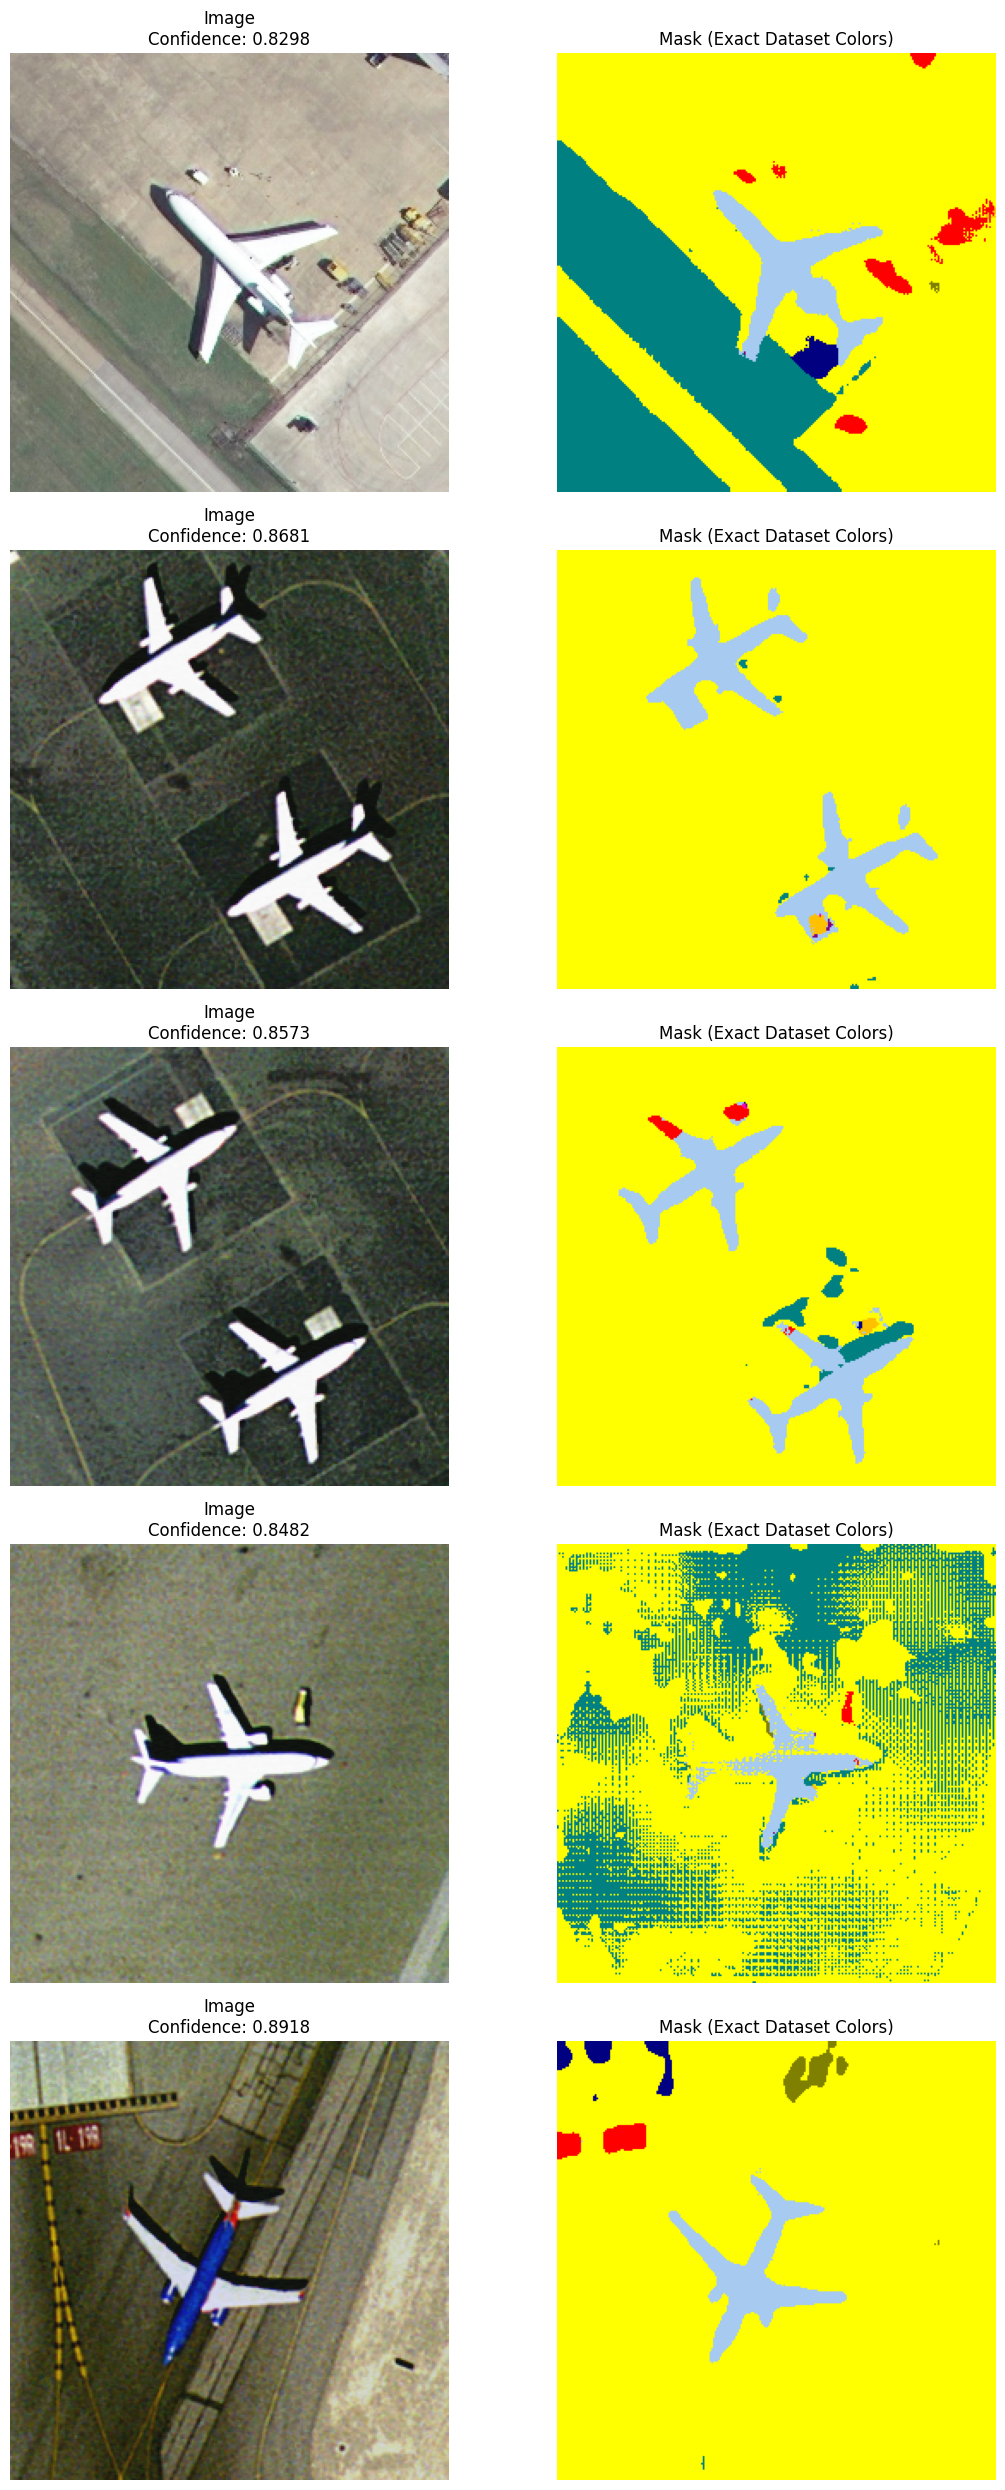

✅ Visualization saved as 'top_confident_samples_exact_colors.png'

📁 EXTRACTED FILES SUMMARY:
Images in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/top_10_percent_images: 131
Masks in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/top_10_percent_masks: 131

Sample files (first 3):
  - airpl_836_conf_0.8298.png → Confidence: 0.8298
  - airpl_843_conf_0.8681.png → Confidence: 0.8681
  - airpl_844_conf_0.8573.png → Confidence: 0.8573


In [3]:
import pandas as pd
import os
import shutil
from glob import glob
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ==================== CONFIGURATION ====================
CONFIDENCE_CSV_PATH = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/pseudo_confidence_scores.csv"
PSEUDO_IMAGES_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_test_images'
PSEUDO_MASKS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/topo_refined_predictions'

# Output directories for top 10%
TOP_10_IMAGES_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/top_10_percent_images'
TOP_10_MASKS_DIR = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/top_10_percent_masks'

# Create output directories
os.makedirs(TOP_10_IMAGES_DIR, exist_ok=True)
os.makedirs(TOP_10_MASKS_DIR, exist_ok=True)

# ==================== YOUR EXACT COLOR MAP ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def extract_top_10_percent():
    print("=== EXTRACTING TOP 10% MOST CONFIDENT PSEUDO IMAGES ===")
    
    # Load confidence scores
    df = pd.read_csv(CONFIDENCE_CSV_PATH)
    print(f"Total pseudo images: {len(df)}")
    
    # Calculate top 10% threshold
    top_10_count = max(1, len(df) // 10)  # At least 1 image
    print(f"Top 10% will contain: {top_10_count} images")
    
    # Sort by confidence (descending) and take top 10%
    top_df = df.nlargest(top_10_count, 'confidence')
    
    print("\n📊 Confidence Range in Top 10%:")
    print(f"  Highest: {top_df['confidence'].max():.4f}")
    print(f"  Lowest: {top_df['confidence'].min():.4f}")
    print(f"  Average: {top_df['confidence'].mean():.4f}")
    
    # Copy images and masks
    copied_count = 0
    missing_files = []
    
    for idx, row in top_df.iterrows():
        image_name = row['image_name']
        confidence = row['confidence']
        
        # Source paths
        src_image_path = os.path.join(PSEUDO_IMAGES_DIR, image_name)
        src_mask_path = os.path.join(PSEUDO_MASKS_DIR, 
                                   image_name.replace('.jpg', '.png').replace('.jpeg', '.png'))
        
        # Destination paths (include confidence in filename for easy identification)
        base_name = os.path.splitext(image_name)[0]
        dst_image_path = os.path.join(TOP_10_IMAGES_DIR, f"{base_name}_conf_{confidence:.4f}.png")
        dst_mask_path = os.path.join(TOP_10_MASKS_DIR, f"{base_name}_conf_{confidence:.4f}.png")
        
        # Copy files if they exist
        if os.path.exists(src_image_path) and os.path.exists(src_mask_path):
            shutil.copy2(src_image_path, dst_image_path)
            shutil.copy2(src_mask_path, dst_mask_path)
            copied_count += 1
            print(f"✅ Copied: {image_name} (conf: {confidence:.4f})")
        else:
            missing_files.append(image_name)
            print(f"❌ Missing: {image_name}")
    
    print(f"\n🎯 EXTRACTION COMPLETE:")
    print(f"  Successfully copied: {copied_count}/{top_10_count} images")
    print(f"  Output directory: {TOP_10_IMAGES_DIR}")
    print(f"  Masks directory: {TOP_10_MASKS_DIR}")
    
    if missing_files:
        print(f"⚠️  Missing files: {len(missing_files)}")
        for missing in missing_files[:5]:  # Show first 5
            print(f"    - {missing}")
    
    return copied_count

def visualize_top_confident_samples(num_samples=5):
    """Visualize with EXACT color map - NO OVERLAYS"""
    print(f"\n=== VISUALIZING TOP {num_samples} CONFIDENT SAMPLES ===")
    
    top_images = sorted(glob(os.path.join(TOP_10_IMAGES_DIR, "*.png")))[:num_samples]
    
    if not top_images:
        print("No images found to visualize!")
        return
    
    def mask_to_color(mask):
        """Convert class indices to RGB colors using EXACT class colors"""
        h, w = mask.shape
        color_mask = np.zeros((h, w, 3), dtype=np.uint8)
        for class_id, class_info in CLASS_INFO.items():
            color_mask[mask == class_id] = class_info["rgb"]
        return color_mask
    
    # 2 columns: Image + Mask (no overlay column)
    fig, axes = plt.subplots(num_samples, 2, figsize=(12, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx, image_path in enumerate(top_images):
        if idx >= num_samples:
            break
            
        # Get corresponding mask path
        base_name = os.path.basename(image_path)
        mask_path = os.path.join(TOP_10_MASKS_DIR, base_name)
        
        # Load image and mask
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if image is None:
            print(f"❌ Could not load image: {image_path}")
            continue
        if mask is None:
            print(f"❌ Could not load mask: {mask_path}")
            continue
        
        # Convert mask to EXACT colors
        color_mask = mask_to_color(mask)
        
        # Extract confidence from filename
        confidence = float(base_name.split('_conf_')[1].replace('.png', ''))
        
        # Plot - CLEAN SIDE-BY-SIDE
        axes[idx, 0].imshow(image)
        axes[idx, 0].set_title(f'Image\nConfidence: {confidence:.4f}', fontsize=12)
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(color_mask)  # EXACT COLORS!
        axes[idx, 1].set_title('Mask (Exact Dataset Colors)', fontsize=12)
        axes[idx, 1].axis('off')
    
    plt.tight_layout()
    plt.savefig('/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/top_confident_samples_exact_colors.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Visualization saved as 'top_confident_samples_exact_colors.png'")

def print_class_legend():
    """Print a legend showing class names and colors"""
    print("\n🎨 CLASS LEGEND:")
    print("=" * 50)
    for class_id, class_info in CLASS_INFO.items():
        rgb = class_info["rgb"]
        print(f"Class {class_id:2d}: {class_info['name']:12} → RGB{tuple(rgb)}")

# ==================== MAIN ====================
if __name__ == "__main__":
    # Show class legend first
    print_class_legend()
    
    # Extract top 10%
    copied_count = extract_top_10_percent()
    
    # Visualize if we have samples
    if copied_count > 0:
        visualize_top_confident_samples(min(5, copied_count))
        
        # Print summary of extracted files
        print(f"\n📁 EXTRACTED FILES SUMMARY:")
        print(f"Images in {TOP_10_IMAGES_DIR}: {len(os.listdir(TOP_10_IMAGES_DIR))}")
        print(f"Masks in {TOP_10_MASKS_DIR}: {len(os.listdir(TOP_10_MASKS_DIR))}")
        
        # Show first few filenames with confidence
        image_files = sorted(os.listdir(TOP_10_IMAGES_DIR))[:3]
        print(f"\nSample files (first 3):")
        for file in image_files:
            confidence = float(file.split('_conf_')[1].replace('.png', ''))
            print(f"  - {file} → Confidence: {confidence:.4f}")
            
    else:
        print("❌ No files were copied. Check file paths and permissions.")